# Items or Relations? — Auto-associators under biologically plausible learning rules

**A single, self-contained notebook. No external repositories, no `git clone`, no `pip install`.**

This notebook reproduces the experiments of

> Krause, R. & Reimann, S. (2024). *Items or Relations — what do Artificial Neural Networks learn?* [arXiv:2404.12401](https://arxiv.org/abs/2404.12401)

and extends them along a new axis: instead of only backpropagation, the auto-associator is trained with the **local, biologically plausible learning rules** of

> Galloni, A. & Milstein, A. (2026). *Cell Reports* — [EIANN framework](https://github.com/Milstein-Lab/EIANN)

The relevant parts of EIANN (population/projection/network engine, the training loop, the learning
rules, the weight constraints) are **reimplemented from scratch in Part III** in ~250 lines of PyTorch,
so the notebook runs anywhere with `torch`, `numpy`, `matplotlib` and `sympy` — all preinstalled on
Google Colab.

---

## The question

A 3→3 network $y = \varphi(Wx)$ is trained to reproduce a set of binary training items identically,
$\varphi(Wx) = x$ for all $x \in X$. Afterwards: has it stored the **items**, or the **relations**
between them (their symmetry group)?

Two training sets, chosen to have the *same* symmetry group $\Sigma = \{e, (32)\}$:

$$X = \left\{ (1,0,1)^\top,\ (1,1,0)^\top \right\} \qquad
  X' = \left\{ (0,1,0)^\top,\ (0,0,1)^\top \right\}$$

## What is in here

| Part | Content |
|---|---|
| **I** | Symmetry group, orbits, $\Sigma$-compatible weight structure, analytical solution families — **verified symbolically with SymPy** |
| **II** | Reference numerical solutions: SGD / Adam $\times$ {zeros, ones, uniform, Gaussian} init $\times$ {linear, tanh, sigmoid}. Reproduces the paper's published matrices, Table 1, and the $\mathbf{E}[W]$ symmetry-recovery result |
| **III** | **`minieiann`** — self-contained reimplementation of the EIANN engine and eight learning rules |
| **IV** | The learning-rule experiment: 8 rules $\times$ 3 activations $\times$ 2 training sets |
| **V** | Analysis: generalization tables, eigen-spectra, plane-attractor diagnostics, flow fields (paper Fig. 1) |
| **VI** | Summary |

---

## Corrections made relative to the original draft notebook

The notebook this one replaces had several substantive problems. They are listed here because they
change the conclusions, not just the cosmetics:

1. **The learning rules never actually trained.** The unsupervised rules were built through
   `NetworkBuilder`, which left `weight.requires_grad = False` *and* — more importantly — selected
   `Hebb_WeightNorm`, `Ojas_rule` and `BCM_4`. These three rules **never see the target**. The
   resulting weight matrices for "Hebbian", "Oja" and "BCM" were identical to ~4 decimal places
   (they were all essentially the random initialization), and the train loss sat at 0.345 for all
   three. EIANN's *supervised* variants (`Supervised_Hebb_WeightNorm_4`, `Supervised_BCM_4`,
   `Top_Layer_BP_like_2E`, `BTSP_19`) are the ones that receive the target through the backward
   nudging phase; those are used here, with the unsupervised versions kept only as controls.
2. **`Backprop` bypassed the framework entirely** — it fell through to a hand-written
   `torch.optim.Adam` loop, so the "comparison across learning rules" compared one rule run in
   PyTorch against three rules that were not learning.
3. **`bias=False` did not disable the bias.** In EIANN's builder, `bias=False` simply skips setting
   `include_bias`, and a `Population` still allocates an `OutputE_bias` parameter (visible in the
   old output). The paper's model is $y=\varphi(Wx)$ with no bias.
4. **The test set was wrong.** Its 7 columns contained $(0,1,1)$ twice and omitted $(1,1,1)$, so the
   generalization table double-counted one pattern and silently dropped another.
5. **The second training set $X'$ was missing.** `analytical_W_prime_linear` was defined and never
   called. This matters: **Table 1 of the paper is computed on $X'$, not on $X$** — the four items
   the linear network reproduces exactly, $(0,1,0), (0,0,1), (0,0,0), (0,1,1)$, are the binary points
   in $\mathrm{span}(X')$. On $X$ only $(0,0,0)$ is recovered, which is why the old table did not
   match the paper.
6. **SGD was never run**, although the paper's central claim in §3.1.1 is that SGD and Adam land on
   *different* members of the solution family. Both are run here, and the zeros/ones-init solutions
   match the paper's published matrices to 4 decimals.
7. **The $\mathbf{E}[W]$ result was missing.** A single random-init run breaks the $(32)$ symmetry;
   only the average over realizations restores it. This is reproduced in Part II.
8. **Eigenvalue formula.** The paper states $\sigma_W = \{1-a-2b, 1, 1\}$ with stability iff
   $|a-2b|<1$. Symbolic computation gives $\sigma_W = \{1-a+2b, 1, 1\}$, so the stability condition
   is $|1-a+2b|<1$. The sign of $b$ is inconsistent between the two statements in the paper; the
   verified expression is used throughout and the check is shown in Part I.
9. Minor: unused `scipy.optimize` import, `X_train`/`X_test` defined twice with different values in
   the same cell, `analyze_flow_field` shadowing its loop variable, and duplicated
   plotting/analysis code across the two cells.

In [ ]:
# ============================================================================
# Setup — everything below is available in a stock Google Colab runtime.
# Nothing is cloned, nothing is pip-installed.
# ============================================================================
from __future__ import annotations

import itertools
import math
from collections import OrderedDict
from dataclasses import dataclass, field
from typing import Callable, Dict, List, Optional, Sequence

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

try:
    import sympy as sp
    HAVE_SYMPY = True
except ImportError:                                   # pragma: no cover
    HAVE_SYMPY = False
    print("sympy not found — Part I will fall back to numeric verification.")

# Reproducibility -------------------------------------------------------------
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
torch.set_printoptions(precision=4, sci_mode=False)
np.set_printoptions(precision=4, suppress=True, linewidth=120)

DEVICE = torch.device("cpu")   # the model is 3x3; CPU is faster than any GPU here

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 9,
    "axes.titlesize": 10,
})

print(f"torch {torch.__version__} | numpy {np.__version__} | device {DEVICE}")

torch 2.11.0+cpu | numpy 2.0.2 | device cpu


---
# Part I — Analytical prelude

The group of admissible operations is the symmetric group $S_3$ acting on index positions,
$(s\cdot x)_i = x_{s(i)}$. The **symmetry group of a set** is the subgroup that leaves the set
invariant. A map $\varphi_W$ is $\Sigma_X$-*compatible* iff $W = s\cdot W$ for all $s\in\Sigma_X$,
where $(s\cdot W)_{ij} = W_{s(i)s(j)}$.

Everything in this part is computed, not asserted: the symmetry groups are found by brute force over
$S_3$, the compatible weight structure is derived by solving $W = s\cdot W$, and the solution
families and their spectra are obtained with SymPy.

In [ ]:
# ============================================================================
# I.1  Training sets, the group S_3, symmetry groups and orbits
# ============================================================================

# Items are stored as ROWS (n_items, 3). Columns-as-items is used only where a
# matrix product needs it, and is then written explicitly as `.T`.
X_SETS = {
    "X":  np.array([[1., 0., 1.],
                    [1., 1., 0.]]),
    "X'": np.array([[0., 1., 0.],
                    [0., 0., 1.]]),
}

# All 8 binary patterns of length 3 - the universe of test items.
ALL_PATTERNS = np.array(list(itertools.product([0., 1.], repeat=3)))


def permute_vector(x, s):
    """Group action on a pattern:  (s . x)_i = x_{s(i)}."""
    return np.array([x[s[i]] for i in range(len(x))])


def permute_matrix(W, s):
    """Group action on a weight matrix:  (s . W)_ij = W_{s(i) s(j)}."""
    idx = np.array(s)
    return W[np.ix_(idx, idx)]


def symmetry_group(items):
    """All s in S_3 that leave the SET of items invariant."""
    rows = {tuple(r) for r in items}
    keep = []
    for s in itertools.permutations(range(items.shape[1])):
        if {tuple(permute_vector(np.array(r), s)) for r in rows} == rows:
            keep.append(s)
    return keep


def cycle_notation(s):
    """Human-readable cycle notation, 1-indexed, matching the paper."""
    seen, cycles = set(), []
    for i in range(len(s)):
        if i in seen or s[i] == i:
            seen.add(i)
            continue
        cyc, j = [], i
        while j not in seen:
            seen.add(j); cyc.append(j); j = s[j]
        cycles.append(cyc)
    return "e" if not cycles else "".join("(" + "".join(str(k + 1) for k in c) + ")" for c in cycles)


def orbits(items, group):
    """Partition of `items` into orbits under `group`."""
    remaining = [tuple(r) for r in items]
    out = []
    while remaining:
        x = remaining.pop(0)
        orb = {tuple(permute_vector(np.array(x), s)) for s in group}
        out.append(sorted(orb))
        remaining = [r for r in remaining if tuple(r) not in orb]
    return out


for name, items in X_SETS.items():
    G = symmetry_group(items)
    print(f"{name} = {{{', '.join(str(tuple(int(v) for v in r)) for r in items)}}}")
    print(f"    symmetry group  Sigma = {{{', '.join(cycle_notation(s) for s in G)}}}   (order {len(G)})")
    for orb in orbits(items, G):
        print(f"    orbit: {[tuple(int(v) for v in o) for o in orb]}")
    print()

assert symmetry_group(X_SETS["X"]) == symmetry_group(X_SETS["X'"]), \
    "the two training sets are supposed to share a symmetry group"
SIGMA = symmetry_group(X_SETS["X"])
print(f"Both training sets share Sigma = {{{', '.join(cycle_notation(s) for s in SIGMA)}}} "
      "-> they must share the same compatible weight structure.")

X = {(1, 0, 1), (1, 1, 0)}
    symmetry group  Sigma = {e, (23)}   (order 2)
    orbit: [(1, 0, 1), (1, 1, 0)]

X' = {(0, 1, 0), (0, 0, 1)}
    symmetry group  Sigma = {e, (23)}   (order 2)
    orbit: [(0, 0, 1), (0, 1, 0)]

Both training sets share Sigma = {e, (23)} -> they must share the same compatible weight structure.


In [ ]:
# ============================================================================
# I.2  Sigma-compatible weight structure, solution families, spectra
# ============================================================================

def compatible_structure_mask(group, n=3):
    """
    Solve W = s.W for all s in `group` by finding the orbits of the index pairs
    (i, j) under (i, j) -> (s(i), s(j)). Entries in the same orbit must be equal.
    Returns an (n, n) integer array labelling the free parameters.
    """
    label = -np.ones((n, n), dtype=int)
    nxt = 0
    for i in range(n):
        for j in range(n):
            if label[i, j] >= 0:
                continue
            orb = {(s[i], s[j]) for s in group}
            for (a, b) in orb:
                label[a, b] = nxt
            nxt += 1
    return label


mask = compatible_structure_mask(SIGMA)
letters = np.array(list("abcdefghi"))[mask]
print("Sigma-compatible weight structure (equal letters = tied entries):")
for row in letters:
    print("   [" + "  ".join(row) + "]")
print(f"   -> {mask.max() + 1} free parameters\n")

# --- The paper's eq. 5 is [[a,b,b],[c,d,e],[c,e,d]]; check we recovered it ----
expected = np.array([[0, 1, 1], [2, 3, 4], [2, 4, 3]])
assert np.array_equal(mask, expected), f"structure mismatch:\n{mask}"
print("Matches eq. 5 of the paper:  W = [[a, b, b], [c, d, e], [c, e, d]]\n")

# --- Solve the fixed-point equations on this structure ----------------------
if HAVE_SYMPY:
    A, B, C, D, E, a_, b_ = sp.symbols("A B C D E a b", real=True)
    W_sym = sp.Matrix([[A, B, B], [C, D, E], [C, E, D]])

    for name, items in X_SETS.items():
        eqs = []
        for row in items:
            v = sp.Matrix([sp.Rational(int(t)) for t in row])
            eqs += list(W_sym * v - v)
        sol = sp.solve(eqs, [A, B, C, D, E], dict=True)[0]
        W_gen = sp.simplify(W_sym.subs(sol))
        free = sorted(W_gen.free_symbols, key=str)
        print(f"Linear auto-associator family for {name}   (free: {', '.join(map(str, free))}):")
        sp.pprint(W_gen)
        print("   spectrum:", {str(k): v for k, v in W_gen.eigenvals().items()}, "\n")

    # ---- the paper's two families, re-derived and re-parameterised ----------
    W_ab = sp.Matrix([[1 - a_, a_, a_], [-b_, 1 + b_, b_], [-b_, b_, 1 + b_]])
    Wp_ab = sp.Matrix([[a_, 0, 0], [b_, 1, 0], [b_, 0, 1]])
    print("Paper eq. 6, verified:")
    print("   W_ab  fixes X  :", all(sp.simplify(W_ab * sp.Matrix(list(map(int, r)))) ==
                                     sp.Matrix(list(map(int, r))) for r in X_SETS["X"]))
    print("   W'_ab fixes X' :", all(sp.simplify(Wp_ab * sp.Matrix(list(map(int, r)))) ==
                                     sp.Matrix(list(map(int, r))) for r in X_SETS["X'"]))
    print("   sigma(W_ab)  =", {str(k): v for k, v in W_ab.eigenvals().items()})
    print("   sigma(W'_ab) =", {str(k): v for k, v in Wp_ab.eigenvals().items()})
    print()
    print("   NOTE: the paper prints sigma(W_ab) = {1 - a - 2b, 1, 1} and a stability")
    print("         condition |a - 2b| < 1. The symbolic result is 1 - a + 2b, so the")
    print("         plane spanned by X is an attractor iff |1 - a + 2b| < 1.")
    print("         For W' the paper's {a, 1, 1} and |a| < 1 are confirmed.")


def analytical_W(a, b):
    """Family of linear auto-associators on X (paper eq. 6, left)."""
    return np.array([[1 - a, a, a], [-b, 1 + b, b], [-b, b, 1 + b]])


def analytical_W_prime(a, b):
    """Family of linear auto-associators on X' (paper eq. 6, right)."""
    return np.array([[a, 0., 0.], [b, 1., 0.], [b, 0., 1.]])


# numeric cross-check of the corrected spectrum
for a, b in [(0.3, -0.4), (0.5, -0.5), (1.0 / 3, -1.0 / 3), (0.0, 0.25)]:
    lam = np.sort(np.linalg.eigvals(analytical_W(a, b)).real)
    print(f"a={a:+.4f} b={b:+.4f} -> eig {np.round(lam, 4)}   1-a+2b = {1 - a + 2 * b:+.4f}")

Sigma-compatible weight structure (equal letters = tied entries):
   [a  b  b]
   [c  d  e]
   [c  e  d]
   -> 5 free parameters

Matches eq. 5 of the paper:  W = [[a, b, b], [c, d, e], [c, e, d]]

Linear auto-associator family for X   (free: B, E):
⎡1 - B    B      B  ⎤
⎢                   ⎥
⎢ -E    E + 1    E  ⎥
⎢                   ⎥
⎣ -E      E    E + 1⎦
   spectrum: {'1': 2, '-B + 2*E + 1': 1} 

Linear auto-associator family for X'   (free: A, C):
⎡A  0  0⎤
⎢       ⎥
⎢C  1  0⎥
⎢       ⎥
⎣C  0  1⎦
   spectrum: {'A': 1, '1': 2} 

Paper eq. 6, verified:
   W_ab  fixes X  : True
   W'_ab fixes X' : True
   sigma(W_ab)  = {'1': 2, '-a + 2*b + 1': 1}
   sigma(W'_ab) = {'a': 1, '1': 2}

   NOTE: the paper prints sigma(W_ab) = {1 - a - 2b, 1, 1} and a stability
         condition |a - 2b| < 1. The symbolic result is 1 - a + 2b, so the
         plane spanned by X is an attractor iff |1 - a + 2b| < 1.
         For W' the paper's {a, 1, 1} and |a| < 1 are confirmed.
a=+0.3000 b=-0.4000 -> eig

---
# Part II — Reference numerical solutions (standard optimizers)

Before introducing local learning rules, we reproduce the paper's own numerical experiments with
plain PyTorch: minimise $\frac{1}{N}\sum_i(\hat{x}_i - x_i)^2$ over the training set with SGD or Adam,
from four initializations (zeros, ones, $\mathcal{U}(0,1)$, $\mathcal{N}(0, 0.05)$) and three
activations.

Two claims are checked quantitatively:

* **§3.1.1** — every converged solution is a member of the analytical family, and *which* member is
  set by the optimizer and the initialization. The zeros- and ones-init SGD solutions should match
  $W_0^{SGD}$ and $W_1^{SGD}$ as printed in the paper.
* **§3.1.1, end** — a *single* random-init run breaks the $(32)$ symmetry (rows 2 and 3 are no longer
  mirror images); only $\mathbf{E}[W]$ over realizations restores it.

In [ ]:
# ============================================================================
# II.1  Reference trainer (plain PyTorch, no framework)
# ============================================================================

ACT_NP = {
    "linear":  lambda s: s,
    "tanh":    np.tanh,
    "sigmoid": lambda s: 1.0 / (1.0 + np.exp(-s)),
}
ACT_TORCH = {
    "linear":  lambda s: s,
    "tanh":    torch.tanh,
    "sigmoid": torch.sigmoid,
}


def init_weight(kind, n=3, seed=None):
    """The four initializations used in the paper."""
    g = torch.Generator().manual_seed(GLOBAL_SEED if seed is None else seed)
    if kind == "zeros":
        return torch.zeros(n, n)
    if kind == "ones":
        return torch.ones(n, n)
    if kind == "uniform":                       # U(0, 1)
        return torch.rand(n, n, generator=g)
    if kind == "gaussian":                      # N(0, 0.05)
        return torch.randn(n, n, generator=g) * 0.05
    if kind == "normal1":                       # N(0, 1)
        return torch.randn(n, n, generator=g)
    raise ValueError(f"unknown init: {kind}")


def train_reference(items, activation="linear", init="zeros", optimizer="SGD",
                    lr=None, steps=20_000, seed=None, full_batch=True):
    """
    Minimise the paper's cost (eq. 7) for y = phi(W x).  Returns (W, loss_history).

    `full_batch=True` is gradient descent on the whole training set; `False` draws one
    item per step (true SGD).  Both converge to the same solution for the linear case.
    """
    if lr is None:
        lr = 0.5 if optimizer == "SGD" else 0.01
    W = nn.Parameter(init_weight(init, items.shape[1], seed).clone())
    opt = (torch.optim.SGD([W], lr=lr) if optimizer == "SGD"
           else torch.optim.Adam([W], lr=lr))
    phi = ACT_TORCH[activation]
    data = torch.as_tensor(items, dtype=torch.float32)      # (n_items, 3)
    rng = np.random.default_rng(GLOBAL_SEED if seed is None else seed)

    hist = []
    for _ in range(steps):
        batch = data if full_batch else data[rng.integers(len(data))].unsqueeze(0)
        out = phi(batch @ W.T)                              # row i  ==  phi(W x_i)
        loss = torch.mean((out - batch) ** 2)
        opt.zero_grad()
        loss.backward()
        opt.step()
        hist.append(loss.item())
    return W.detach().numpy().copy(), np.asarray(hist)


# ---------------------------------------------------------------------------
# Shared analysis helpers, used by Part II and Part V alike
# ---------------------------------------------------------------------------
def net_output(W, patterns, activation="linear"):
    """Apply y = phi(W x) to a stack of row-patterns."""
    return ACT_NP[activation](patterns @ W.T)


def pattern_loss(W, patterns, activation="linear"):
    """Per-pattern cost (paper eq. 7)."""
    return np.mean((net_output(W, patterns, activation) - patterns) ** 2, axis=1)


def symmetry_report(W, group=None, atol=1e-3):
    """
    Fraction of Sigma-tied entry pairs that actually agree, plus the residual
    ||W - s.W|| maximised over the group.  A perfectly Sigma-compatible W scores 1.0 / 0.0.
    """
    group = SIGMA if group is None else group
    resid = max(float(np.abs(W - permute_matrix(W, s)).max()) for s in group)
    lab = compatible_structure_mask(group, W.shape[0])
    ok = tot = 0
    for k in range(lab.max() + 1):
        vals = W[lab == k]
        if vals.size > 1:
            tot += 1
            ok += int(np.ptp(vals) < atol)
    return (ok / tot if tot else 1.0), resid


def spectrum(W):
    """Eigenvalues sorted by decreasing modulus."""
    ev = np.linalg.eigvals(W)
    return ev[np.argsort(-np.abs(ev))]


def is_plane_attractor(W, tol=5e-2):
    """
    The paper's diagnostic: two eigenvalues equal to 1 (the invariant plane) and a
    third with modulus < 1 (contraction onto it).
    """
    ev = spectrum(W)
    unit = np.abs(ev - 1.0) < tol
    return bool(unit.sum() >= 2 and np.abs(ev[np.argsort(np.abs(ev))][0]) < 1 - tol)


print("Reference trainer ready.")

Reference trainer ready.


In [ ]:
# ============================================================================
# II.2  Reproducing the published matrices  (paper section 3.1.1)
# ============================================================================
PAPER_MATRICES = {
    ("zeros", "SGD"): np.array([[0.6667,  0.3330,  0.3330],
                                [0.3333,  0.6667, -0.3333],
                                [0.3333, -0.3333,  0.6667]]),
    ("ones", "SGD"):  np.array([[0.3333,  0.6667,  0.6667],
                                [0.0000,  1.0000,  0.0000],
                                [0.0000,  0.0000,  1.0000]]),
    ("zeros", "Adam"): np.array([[0.5496,  0.4500,  0.4504],
                                 [0.4995,  0.5005, -0.4996],
                                 [0.4996, -0.4996,  0.5004]]),
    ("ones", "Adam"):  np.array([[0.4504,  0.5496,  0.5496],
                                 [0.0522,  0.9478, -0.0522],
                                 [0.0489, -0.0489,  0.9511]]),
}

items_X = X_SETS["X"]
reference_solutions = {}

print("Training set X, linear activation\n" + "=" * 78)
for init in ("zeros", "ones", "uniform", "gaussian"):
    for opt in ("SGD", "Adam"):
        W, hist = train_reference(items_X, "linear", init, opt, steps=20_000)
        reference_solutions[(init, opt)] = W
        frac, resid = symmetry_report(W)
        ev = spectrum(W)
        print(f"\ninit={init:<9} optimizer={opt:<5} train cost={hist[-1]:.3e}")
        print("   W =", np.array2string(W, prefix="        "))
        print(f"   eigenvalues      : {np.round(ev.real, 4)}")
        print(f"   Sigma-compatible : {frac:.0%} of tied pairs agree, max||W - s.W|| = {resid:.2e}")
        print(f"   plane attractor  : {is_plane_attractor(W)}")

        ref = PAPER_MATRICES.get((init, opt))
        if ref is not None:
            print(f"   vs. paper        : max abs deviation = {np.abs(W - ref).max():.4f}")

# ---- assert the two SGD solutions really are the paper's ------------------
for key in (("zeros", "SGD"), ("ones", "SGD")):
    dev = np.abs(reference_solutions[key] - PAPER_MATRICES[key]).max()
    assert dev < 1e-3, f"{key}: deviation {dev:.4f} from the published matrix"
print("\nBoth published SGD matrices reproduced to < 1e-3.")

# ---- and that every solution is a member of the analytical family ---------
print("\nRecovered family parameters  W = [[1-a, a, a], [-b, 1+b, b], [-c, c, 1+c]]:")
for (init, opt), W in reference_solutions.items():
    a, b, c = W[0, 1], -W[1, 0], -W[2, 0]
    fit = np.array([[1 - a, a, a], [-b, 1 + b, b], [-c, c, 1 + c]])
    print(f"   {init:<9} {opt:<5} a={a:+.4f} b={b:+.4f} c={c:+.4f}   "
          f"residual={np.abs(W - fit).max():.2e}   (symmetric iff b == c)")

Training set X, linear activation

init=zeros     optimizer=SGD   train cost=7.105e-15
   W = [[ 0.6667  0.3333  0.3333]
         [ 0.3333  0.6667 -0.3333]
         [ 0.3333 -0.3333  0.6667]]
   eigenvalues      : [ 1.  1. -0.]
   Sigma-compatible : 100% of tied pairs agree, max||W - s.W|| = 0.00e+00
   plane attractor  : True
   vs. paper        : max abs deviation = 0.0003

init=zeros     optimizer=Adam  train cost=3.070e-12
   W = [[ 0.5     0.5     0.5   ]
         [ 0.4997  0.5003 -0.4997]
         [ 0.4997 -0.4997  0.5003]]
   eigenvalues      : [ 1.      1.     -0.4994]
   Sigma-compatible : 100% of tied pairs agree, max||W - s.W|| = 0.00e+00
   plane attractor  : True
   vs. paper        : max abs deviation = 0.0500

init=ones      optimizer=SGD   train cost=6.732e-29
   W = [[ 0.3333  0.6667  0.6667]
         [ 0.      1.     -0.    ]
         [ 0.     -0.      1.    ]]
   eigenvalues      : [1.     1.     0.3333]
   Sigma-compatible : 100% of tied pairs agree, max||W - s.W|| 

single realizations : 40.0% of runs are fully Sigma-compatible (tolerance 1e-2)
                      mean max||W - s.W|| = 0.0303

Example single realizations (note rows 2 and 3 are NOT mirror images):
[[ 0.6449  0.3551  0.3551]
    [ 0.3654  0.6346 -0.3654]
    [ 0.3407 -0.3407  0.6593]]
[[ 0.6813  0.3187  0.3187]
    [ 0.3139  0.6861 -0.3139]
    [ 0.3546 -0.3546  0.6454]]

E[W] over 200 realizations:
[[ 0.6633  0.3367  0.3367]
    [ 0.3333  0.6667 -0.3333]
    [ 0.3355 -0.3355  0.6645]]
   Sigma-compatible : 100% of tied pairs agree, max||W - s.W|| = 0.0021
   eigenvalues      : [ 1.      1.     -0.0055]
   paper reports    : E W_rnd^SGD ~ [[0.6668, 0.3328, 0.3329], [0.3332, 0.6672, -0.3328], [0.3332, -0.3328, 0.6671]]


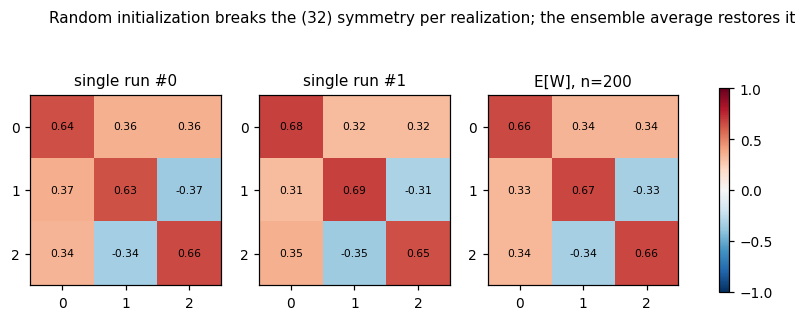

In [ ]:
# ============================================================================
# II.3  A single random-init run breaks the (32) symmetry; E[W] restores it
# ============================================================================
N_REALIZATIONS = 200
realizations = []
for s in range(N_REALIZATIONS):
    W, _ = train_reference(items_X, "linear", "gaussian", "SGD", steps=6_000, seed=1000 + s)
    realizations.append(W)
realizations = np.stack(realizations)

per_run_sym = np.array([symmetry_report(W, atol=1e-2)[0] for W in realizations])
EW = realizations.mean(axis=0)

print(f"single realizations : {per_run_sym.mean():.1%} of runs are fully Sigma-compatible "
      f"(tolerance 1e-2)")
print(f"                      mean max||W - s.W|| = "
      f"{np.mean([symmetry_report(W)[1] for W in realizations]):.4f}")
print("\nExample single realizations (note rows 2 and 3 are NOT mirror images):")
for W in realizations[:2]:
    print(np.array2string(W, prefix="   "))
print("\nE[W] over %d realizations:" % N_REALIZATIONS)
print(np.array2string(EW, prefix="   "))
frac, resid = symmetry_report(EW, atol=1e-2)
print(f"   Sigma-compatible : {frac:.0%} of tied pairs agree, max||W - s.W|| = {resid:.4f}")
print(f"   eigenvalues      : {np.round(spectrum(EW).real, 4)}")
print(f"   paper reports    : E W_rnd^SGD ~ [[0.6668, 0.3328, 0.3329], "
      "[0.3332, 0.6672, -0.3328], [0.3332, -0.3328, 0.6671]]")

fig, axes = plt.subplots(1, 3, figsize=(9.5, 3.0))
for ax, (ttl, M) in zip(axes, [("single run #0", realizations[0]),
                               ("single run #1", realizations[1]),
                               (f"E[W], n={N_REALIZATIONS}", EW)]):
    im = ax.imshow(M, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_title(ttl)
    ax.set_xticks(range(3)); ax.set_yticks(range(3)); ax.grid(False)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=axes, shrink=0.8)
fig.suptitle("Random initialization breaks the (32) symmetry per realization; "
             "the ensemble average restores it", y=1.04, fontsize=10)
plt.show()

In [ ]:
# ============================================================================
# II.4  Generalization (paper Table 1)
#
# IMPORTANT: Table 1 of the paper is computed on the training set X', not X.
# Its first two rows, (0,1,0) and (0,0,1), are the training items, and the
# linear network additionally reproduces (0,0,0) and (0,1,1) exactly -- these
# are precisely the binary points of span(X').
# ============================================================================

# The paper's row order, so the tables can be compared line by line.
TABLE1_ORDER = np.array([[0., 1., 0.], [0., 0., 1.], [0., 0., 0.], [0., 1., 1.],
                         [1., 1., 0.], [1., 0., 1.], [1., 1., 1.], [1., 0., 0.]])

PAPER_TABLE1 = {          # x -> (id, tanh, sigmoid)
    (0, 1, 0): (0.0000, 0.0001, 0.0003), (0, 0, 1): (0.0000, 0.0001, 0.0003),
    (0, 0, 0): (0.0000, 0.0000, 0.2500), (0, 1, 1): (0.0000, 0.0002, 0.1663),
    (1, 1, 0): (0.4251, 0.3008, 0.3099), (1, 0, 1): (0.4251, 0.2459, 0.3100),
    (1, 1, 1): (0.4251, 0.1751, 0.4043), (1, 0, 0): (0.4251, 0.3716, 0.3330),
}


def binary_span_members(items, tol=1e-9):
    """Binary patterns lying in the linear span of the training items."""
    out = []
    for p in ALL_PATTERNS:
        coef, *_ = np.linalg.lstsq(items.T, p, rcond=None)
        if np.allclose(items.T @ coef, p, atol=tol):
            out.append(tuple(int(v) for v in p))
    return out


def generalization_table(items, set_name, activations=("linear", "tanh", "sigmoid"),
                         init="zeros", optimizer="Adam", steps=20_000, compare_paper=False):
    Ws = {a: train_reference(items, a, init, optimizer, steps=steps)[0] for a in activations}
    train_rows = {tuple(int(v) for v in r) for r in items}
    span = set(binary_span_members(items))

    hdr = f"{'x':<10}" + "".join(f"{a:>11}" for a in activations)
    if compare_paper:
        hdr += "   |" + "".join(f"{'paper ' + a[:4]:>13}" for a in activations)
    print(f"\nTable 1 - generalization, training set {set_name} "
          f"({optimizer}, {init} init)\n" + "=" * len(hdr))
    print(hdr)
    print("-" * len(hdr))
    for p in TABLE1_ORDER:
        key = tuple(int(v) for v in p)
        tag = "*" if key in train_rows else ("+" if key in span else " ")
        line = f"{'/'.join(map(str, key)):<7}{tag:<3}"
        for a in activations:
            line += f"{pattern_loss(Ws[a], p[None, :], a)[0]:>11.4f}"
        if compare_paper and key in PAPER_TABLE1:
            line += "   |" + "".join(f"{v:>13.4f}" for v in PAPER_TABLE1[key])
        print(line)
    print("-" * len(hdr))
    print("  * = training item   + = in span(training set), i.e. reachable by a linear map")
    print(f"  binary points of span({set_name}): {sorted(span)}")
    return Ws


Ws_Xp = generalization_table(X_SETS["X'"], "X'", compare_paper=True)
Ws_X = generalization_table(X_SETS["X"], "X")

print("\nWhy the two sets differ despite sharing a symmetry group:")
for nm, it in X_SETS.items():
    print(f"   span({nm}) contains {len(binary_span_members(it))} of the 8 binary patterns "
          f"-> a linear auto-associator can generalize to that many.")


Table 1 - generalization, training set X' (Adam, zeros init)
x              linear       tanh    sigmoid   |   paper line   paper tanh   paper sigm
--------------------------------------------------------------------------------------
0/1/0  *       0.0000     0.0000     0.0000   |       0.0000       0.0001       0.0003
0/0/1  *       0.0000     0.0000     0.0000   |       0.0000       0.0001       0.0003
0/0/0  +       0.0000     0.0000     0.2500   |       0.0000       0.0000       0.2500
0/1/1  +       0.0000     0.0000     0.1667   |       0.0000       0.0002       0.1663
1/1/0          0.3333     0.3333     0.3332   |       0.4251       0.3008       0.3099
1/0/1          0.3333     0.3333     0.3332   |       0.4251       0.2459       0.3100
1/1/1          0.3333     0.3333     0.5000   |       0.4251       0.1751       0.4043
1/0/0          0.3333     0.3333     0.2500   |       0.4251       0.3716       0.3330
--------------------------------------------------------------------

---
# Part III — `minieiann`: a self-contained reimplementation of the EIANN engine

Everything the experiment needs from the EIANN repository, rewritten here. The structure and the
update equations follow `EIANN/network.py` and `EIANN/rules/*.py`; names are kept identical so the
correspondence is checkable line by line.

**What is reproduced**

* `Population` — somatic `state`, `activity`, `prev_activity`, `forward_activity`, `tau`, activation.
  Integration step: $\Delta s = -s + b + \sum_j W_j a_j$, $s \leftarrow s + \Delta s/\tau$,
  $a = \varphi(s)$. With `tau=1, forward_steps=1, bias=0` this collapses to exactly the paper's
  $y=\varphi(Wx)$.
* `Projection` — an `nn.Linear`-style weight with an attached learning rule, optional weight bounds
  and an optional weight constraint.
* `Network.fit` — EIANN's training loop, in order:
  `forward` → `update_forward_state` → rule `backward` (the *nudging* phase) → rule `step` →
  `constrain_weights` → rule `update`.
* Eight learning rules and the `normalize_weight` constraint.

**What is deliberately left out**: E/I cell types and Dale's law, dendritic compartments,
multi-population layers, recurrent projections, convolutional populations, the config-file loader,
and the plotting/optimization suites. None of them are used by a 3→3 auto-associator.

**The one thing worth understanding before reading the code.** EIANN's supervised local rules do not
receive an error signal by backpropagation. Instead the *backward phase nudges the output
population toward the target*:

$$\text{plateau} = \mathrm{clamp}(t - y,\, -1,\, 1), \qquad y_{\text{nudged}} = \varphi(s + \text{plateau})$$

and the weight update is then a purely local product of pre- and post-synaptic quantities evaluated
*after* the nudge. This is what makes `Supervised_Hebb_WeightNorm_4` supervised while
`Hebb_WeightNorm` is not — the distinction the original notebook missed.

In [ ]:
# ============================================================================
# III.1  minieiann - engine
#         mirrors EIANN/network.py (Population, Projection, Network, train loop)
# ============================================================================

# --- activation functions (EIANN/utils/activations.py) ----------------------
def _linear(x):
    return x


def _srelu(x, lo=0.0, hi=1.0):
    """EIANN's default bounded rate activation."""
    return torch.clamp(x, lo, hi)


ACTIVATIONS: Dict[str, Callable] = {
    "linear":  _linear,
    "tanh":    torch.tanh,
    "sigmoid": torch.sigmoid,
    "relu":    torch.relu,
    "srelu":   _srelu,
}

# --- weight constraints (EIANN/rules/weight_functions.py) -------------------
def normalize_weight(projection, scale=1.0):
    """L1-normalise each row of the weight matrix, then rescale by `scale`."""
    w = projection.weight.data
    row_sum = torch.sum(torch.abs(w), dim=1).unsqueeze(1)
    rows = torch.nonzero(row_sum, as_tuple=True)[0]
    w[rows, :] = w[rows, :] / row_sum[rows, :]
    w.mul_(scale)


WEIGHT_CONSTRAINTS: Dict[str, Callable] = {"normalize_weight": normalize_weight}

# --- learning-rule registry -------------------------------------------------
RULES: Dict[str, type] = {}


def register_rule(cls):
    RULES[cls.__name__] = cls
    return cls


# ---------------------------------------------------------------------------
class Population:
    """A group of rate units. Not an nn.Module; parameters live on the Network."""

    def __init__(self, network, layer_name, name, size, activation="linear",
                 tau=None, include_bias=False):
        self.network = network
        self.layer_name = layer_name
        self.name = name
        self.fullname = f"{layer_name}{name}"
        self.size = size
        self.tau = network.tau if tau is None else tau
        self.activation_name = activation
        self.activation = ACTIVATIONS[activation]
        self.include_bias = include_bias
        self.bias = nn.Parameter(torch.zeros(size), requires_grad=False)
        self.projections: List["Projection"] = []
        self.reinit()

    # -- state -------------------------------------------------------------
    def reinit(self):
        self.state = torch.zeros(self.size) + self.bias
        self.activity = self.activation(self.state)
        self.prev_activity = self.activity
        self.forward_activity = self.activity

    def integrate(self):
        """One Euler step of the somatic dynamics (EIANN Population.forward)."""
        delta_state = -self.state + self.bias
        for proj in self.projections:
            src = proj.pre.activity if proj.direction == "forward" else proj.pre.prev_activity
            delta_state = delta_state + proj(src)
        self.state = self.state + delta_state / self.tau
        self.activity = self.activation(self.state)

    def __repr__(self):
        return f"Population({self.fullname}, size={self.size}, act={self.activation_name})"


# ---------------------------------------------------------------------------
class Projection(nn.Module):
    """A weight matrix (post.size x pre.size) plus its learning rule."""

    def __init__(self, pre, post, learning_rule="Backprop", learning_rule_kwargs=None,
                 weight_init="zeros", weight_init_kwargs=None,
                 weight_constraint=None, weight_constraint_kwargs=None,
                 weight_bounds=None, direction="forward", seed=None):
        super().__init__()
        self.pre, self.post = pre, post
        self.name = f"{post.fullname}_{pre.fullname}"
        self.direction = direction
        self.weight = nn.Parameter(torch.zeros(post.size, pre.size), requires_grad=False)
        self.weight_bounds = weight_bounds
        self.init_weight(weight_init, weight_init_kwargs or {}, seed)

        if weight_constraint is None:
            self.constrain_weight = None
        else:
            fn = WEIGHT_CONSTRAINTS[weight_constraint]
            kw = weight_constraint_kwargs or {}
            self.constrain_weight = lambda: fn(self, **kw)
        self.weight_constraint_name = weight_constraint

        rule_cls = RULES[learning_rule] if isinstance(learning_rule, str) else learning_rule
        self.learning_rule = rule_cls(self, **(learning_rule_kwargs or {}))

    def init_weight(self, kind, kwargs, seed):
        g = torch.Generator().manual_seed(GLOBAL_SEED if seed is None else seed)
        n_out, n_in = self.weight.shape
        with torch.no_grad():
            # torch.rand/randn with an explicit generator works on every torch
            # version; Tensor.uniform_(..., generator=) does not.
            if kind == "zeros":
                self.weight.data.zero_()
            elif kind == "ones":
                self.weight.data.fill_(1.0)
            elif kind == "uniform":
                lo, hi = kwargs.get("lo", 0.0), kwargs.get("hi", 1.0)
                self.weight.data.copy_(torch.rand(n_out, n_in, generator=g) * (hi - lo) + lo)
            elif kind == "gaussian":
                mean, std = kwargs.get("mean", 0.0), kwargs.get("std", 0.05)
                self.weight.data.copy_(torch.randn(n_out, n_in, generator=g) * std + mean)
            elif kind == "scaled_kaiming":
                b = kwargs.get("scale", 1.0) / math.sqrt(n_in)
                self.weight.data.copy_((torch.rand(n_out, n_in, generator=g) * 2 - 1) * b)
            elif kind == "half_kaiming":                       # non-negative, for BTSP
                b = kwargs.get("scale", 1.0) / math.sqrt(n_in)
                self.weight.data.copy_(torch.rand(n_out, n_in, generator=g) * b)
            else:
                raise ValueError(f"unknown weight_init: {kind}")

    def forward(self, x):
        return self.weight @ x if x.ndim == 1 else x @ self.weight.T

    def __repr__(self):
        return (f"Projection({self.name}, {tuple(self.weight.shape)}, "
                f"rule={type(self.learning_rule).__name__})")


# ---------------------------------------------------------------------------
class Network(nn.Module):
    """Feed-forward chain of layers, each holding one population."""

    def __init__(self, layer_spec, projection_spec, tau=1, forward_steps=1,
                 learning_rate=0.01, optimizer="SGD", optimizer_kwargs=None,
                 criterion=None, seed=None):
        super().__init__()
        if seed is not None:
            torch.manual_seed(seed)
        self.tau, self.forward_steps = tau, forward_steps
        self.learning_rate = learning_rate
        self.criterion = criterion or nn.MSELoss()
        self.seed = seed

        self.layers: List[List[Population]] = []
        self.populations: "OrderedDict[str, Population]" = OrderedDict()
        for layer_name, pops in layer_spec.items():
            layer = []
            for pop_name, kw in pops.items():
                pop = Population(self, layer_name, pop_name, **kw)
                layer.append(pop)
                self.populations[pop.fullname] = pop
            self.layers.append(layer)
        self.input_pop = self.layers[0][0]
        self.output_pop = self.layers[-1][0]

        self.module_dict = nn.ModuleDict()
        self.projections: "OrderedDict[str, Projection]" = OrderedDict()
        for tgt, sources in projection_spec.items():
            post = self.populations[tgt]
            for src, kw in sources.items():
                pre = self.populations[src]
                proj = Projection(pre, post, seed=seed, **kw)
                post.projections.append(proj)
                self.projections[proj.name] = proj
                self.module_dict[proj.name] = proj
        for pop in self.populations.values():
            pop.reinit()

        # de-duplicated list of rule classes whose `backward` must run each step
        self.backward_classes = []
        for proj in self.projections.values():
            cls = type(proj.learning_rule)
            if cls not in self.backward_classes:
                self.backward_classes.append(cls)

        grad_params = [p for p in self.parameters() if p.requires_grad]
        if grad_params:
            opt_cls = {"SGD": torch.optim.SGD, "Adam": torch.optim.Adam}[optimizer]
            self.optimizer = opt_cls(grad_params, lr=learning_rate,
                                     **(optimizer_kwargs or {}))
        else:
            self.optimizer = None
        self.constrain_weights()

    # -- inference ---------------------------------------------------------
    def forward(self, x):
        for pop in self.populations.values():
            pop.reinit()
        self.input_pop.activity = x
        for _ in range(self.forward_steps):
            for pop in self.populations.values():
                pop.prev_activity = pop.activity
            for layer in self.layers[1:]:
                for pop in layer:
                    pop.integrate()
        return self.output_pop.activity

    def update_forward_state(self):
        for pop in self.populations.values():
            pop.forward_activity = pop.activity.detach().clone()
            pop.forward_prev_activity = pop.prev_activity.detach().clone()

    def constrain_weights(self):
        with torch.no_grad():
            for proj in self.projections.values():
                if proj.weight_bounds is not None:
                    proj.weight.data.clamp_(*proj.weight_bounds)
                if proj.constrain_weight is not None:
                    proj.constrain_weight()

    # -- training ----------------------------------------------------------
    def fit(self, items, targets=None, steps=20_000, seed=0, record_every=200):
        """EIANN's training loop, one sample per step."""
        targets = items if targets is None else targets
        data = torch.as_tensor(np.asarray(items), dtype=torch.float32)
        targ = torch.as_tensor(np.asarray(targets), dtype=torch.float32)
        rng = np.random.default_rng(seed)

        for proj in self.projections.values():
            proj.learning_rule.reinit()

        loss_hist, weight_hist, steps_rec = [], [], []
        for t in range(steps):
            i = int(rng.integers(len(data)))
            x, y = data[i], targ[i]

            out = self.forward(x)                       # keeps the graph for Backprop
            loss_hist.append(float(torch.mean((out.detach() - y) ** 2)))

            self.update_forward_state()
            for cls in self.backward_classes:
                cls.backward(self, out, y)
            for proj in self.projections.values():
                proj.learning_rule.step()
            self.constrain_weights()
            for proj in self.projections.values():
                proj.learning_rule.update()

            if t % record_every == 0 or t == steps - 1:
                steps_rec.append(t)
                weight_hist.append(self.weight_matrix())

        if not np.all(np.isfinite(weight_hist[-1])):
            print(f"  ! WARNING: weights diverged to non-finite values at step {steps}")
        return {"loss": np.asarray(loss_hist),
                "weights": np.stack(weight_hist),
                "steps": np.asarray(steps_rec)}

    # -- convenience -------------------------------------------------------
    def weight_matrix(self, name=None):
        proj = self.projections[name] if name else next(iter(self.projections.values()))
        return proj.weight.detach().cpu().numpy().copy()

    def predict(self, patterns):
        outs = []
        with torch.no_grad():
            for p in np.asarray(patterns, dtype=np.float32):
                outs.append(self.forward(torch.as_tensor(p)).detach().numpy().copy())
        return np.stack(outs)

    def __repr__(self):
        s = [f"Network(tau={self.tau}, forward_steps={self.forward_steps})"]
        for layer in self.layers:
            s += [f"  Layer: " + ", ".join(repr(p) for p in layer)]
        for proj in self.projections.values():
            s += [f"  {proj!r}"]
        return "\n".join(s)


# --- the nudging phase shared by every supervised local rule ---------------
def nudge_output_population(network, target, relu_gate=False):
    """
    EIANN's backward phase for the output layer: compute the local error, store it as
    `plateau`, add it to the somatic state and re-evaluate the activity.
    """
    op = network.output_pop
    local_loss = torch.clamp(target - op.activity.detach(), min=-1.0, max=1.0).clone()
    op.dendritic_state = local_loss.clone()
    if relu_gate:
        local_loss[op.forward_activity == 0.0] = 0.0
    op.plateau = local_loss.clone()
    op.dend_to_soma = local_loss.clone()

    delta_state = -op.state.detach() + op.bias
    for proj in op.projections:
        src = proj.pre.activity if proj.direction == "forward" else proj.pre.prev_activity
        delta_state = delta_state + proj(src.detach())
    op.state = op.state.detach() + delta_state / op.tau
    op.prev_activity = op.activity
    op.activity = op.activation(op.state + op.dend_to_soma)


print("minieiann engine defined.")

minieiann engine defined.


In [ ]:
# ============================================================================
# III.2  minieiann - learning rules
#         mirrors EIANN/rules/{backprop,backprop_like,hebbian,btsp}.py
# ============================================================================

class LearningRule:
    """Base class. `step` updates weights, `update` updates rule state variables."""

    def __init__(self, projection, learning_rate=None):
        self.projection = projection
        self.learning_rate = (projection.post.network.learning_rate
                              if learning_rate is None else learning_rate)

    def reinit(self):
        pass

    def step(self):
        pass

    def update(self):
        pass

    @classmethod
    def backward(cls, network, output, target):
        pass


class _SupervisedNudge:
    """
    Mixin providing EIANN's supervised backward phase: find the projection carrying
    this rule, then nudge the output population toward the target.
    """

    @classmethod
    def backward(cls, network, output, target):
        for proj in network.projections.values():
            if type(proj.learning_rule) is cls:
                with torch.no_grad():
                    nudge_output_population(network, target,
                                            relu_gate=proj.learning_rule.relu_gate)
                break


# ---------------------------------------------------------------------------
# 1. Backprop  (EIANN/rules/backprop.py)
# ---------------------------------------------------------------------------
@register_rule
class Backprop(LearningRule):
    def __init__(self, projection, learning_rate=None):
        super().__init__(projection, learning_rate)
        projection.weight.requires_grad = True

    @classmethod
    def backward(cls, network, output, target):
        loss = network.criterion(output, target)
        network.optimizer.zero_grad()
        loss.backward()
        network.optimizer.step()


# ---------------------------------------------------------------------------
# 2. Top_Layer_BP_like_2E  (EIANN/rules/backprop_like.py)
#    Output units are nudged to target; dw = lr * outer(plateau, pre_activity).
#    For a linear output layer this is exactly the delta rule.
# ---------------------------------------------------------------------------
@register_rule
class Top_Layer_BP_like_2E(_SupervisedNudge, LearningRule):
    def __init__(self, projection, learning_rate=None, relu_gate=True):
        super().__init__(projection, learning_rate)
        # NOTE: EIANN's default is relu_gate=True, which zeroes the plateau wherever
        # forward_activity == 0. With a *linear* activation and a zeros init every
        # output is exactly 0, so the gate would freeze learning permanently.
        # The experiments below therefore pass relu_gate=False explicitly.
        self.relu_gate = relu_gate

    def step(self):
        pre = torch.clamp(self.projection.pre.forward_activity, min=0.0, max=1.0)
        dw = torch.outer(self.projection.post.plateau, pre)
        self.projection.weight.data += self.learning_rate * dw


# ---------------------------------------------------------------------------
# 3. Supervised_Hebb_WeightNorm_4  (EIANN/rules/hebbian.py)
#    Hebbian product of *post-nudge* post and pre activity; kept bounded by the
#    normalize_weight constraint applied after every step.
# ---------------------------------------------------------------------------
@register_rule
class Supervised_Hebb_WeightNorm_4(_SupervisedNudge, LearningRule):
    def __init__(self, projection, sign=1, learning_rate=None, relu_gate=False):
        super().__init__(projection, learning_rate)
        self.sign = sign
        self.relu_gate = relu_gate

    def step(self):
        post = torch.clamp(self.projection.post.activity, min=0.0, max=1.0)
        pre = torch.clamp(self.projection.pre.activity, min=0.0, max=1.0)
        dw = torch.outer(post, pre).detach().clone()
        self.projection.weight.data += self.learning_rate * self.sign * dw


# ---------------------------------------------------------------------------
# 4. Supervised_BCM_4  (EIANN/rules/hebbian.py)
#    dw ~ y (y - theta) x,  with a sliding threshold theta -> <y^2>/k.
# ---------------------------------------------------------------------------
@register_rule
class Supervised_BCM_4(_SupervisedNudge, LearningRule):
    def __init__(self, projection, theta_tau=50.0, k=1.0, sign=1,
                 learning_rate=None, relu_gate=False):
        super().__init__(projection, learning_rate)
        self.theta_tau, self.k, self.sign = theta_tau, k, sign
        self.relu_gate = relu_gate
        projection.post.theta = torch.ones(projection.post.size) * k

    def reinit(self):
        self.projection.post.theta = torch.ones(self.projection.post.size) * self.k

    def step(self):
        y = self.projection.post.activity.detach().clone()
        pre = torch.clamp(self.projection.pre.activity, min=0.0, max=1.0)
        dw = (torch.outer(y, pre) * (y - self.projection.post.theta).unsqueeze(1)).detach()
        self.projection.weight.data += self.learning_rate * self.sign * dw

    def update(self):
        # EIANN guards this with a `BCM_theta_updated` flag so that theta is advanced
        # once per population rather than once per incoming projection. Every network
        # here has exactly one projection per population, so the guard is unnecessary.
        post = self.projection.post
        y = post.activity.detach()
        post.theta = post.theta + (-post.theta + y ** 2 / self.k) / self.theta_tau


# ---------------------------------------------------------------------------
# 5. BTSP_19  (EIANN/rules/btsp.py) - behavioural timescale synaptic plasticity
#    Positive plateaus drive weights toward w_max through an eligibility trace;
#    negative plateaus give a delta-rule-like depression. Includes the one-sample
#    temporal discount of the original.
# ---------------------------------------------------------------------------
def get_scaled_rectified_sigmoid(th, peak, xlim=(0.0, 1.0), ylim=(0.0, 1.0)):
    """EIANN/utils/activations.py - sigmoid rescaled to hit the corners of the box."""
    slope = 2.0 / (peak - th)
    y0 = 1.0 / (1.0 + math.exp(-slope * (xlim[0] - th)))
    y1 = 1.0 / (1.0 + math.exp(-slope * (xlim[1] - th)))
    amp, target_amp = y1 - y0, ylim[1] - ylim[0]
    return lambda x: (target_amp / amp) * (
        1.0 / (1.0 + torch.exp(-slope * (torch.clamp(x, xlim[0], xlim[1]) - th))) - y0) + ylim[0]


@register_rule
class BTSP_19(_SupervisedNudge, LearningRule):
    def __init__(self, projection, dep_ratio=1.0, dep_th=0.01, dep_width=0.01,
                 temporal_discount=0.25, learning_rate=None, relu_gate=False, w_max=None):
        super().__init__(projection, learning_rate)
        self.q_dep = get_scaled_rectified_sigmoid(dep_th, dep_th + dep_width)
        self.dep_ratio = dep_ratio
        self.temporal_discount = temporal_discount
        self.relu_gate = relu_gate
        if w_max is None:
            wb = projection.weight_bounds
            w_max = 2.0 if (wb is None or wb[1] is None) else wb[1]
        self.w_max = w_max

    def reinit(self):
        self.projection.pre.past_activity = torch.zeros(self.projection.pre.size)
        self.projection.post.past_plateau = torch.zeros(self.projection.post.size)

    def _btsp_term(self, plateau_prob, ET, IS):
        w = self.projection.weight.data
        return plateau_prob * ((self.w_max - w) * (ET * IS).unsqueeze(0)
                               - w * self.dep_ratio * self.q_dep(ET * IS).unsqueeze(0))

    def step(self):
        post, pre = self.projection.post, self.projection.pre
        plateau = post.plateau.detach().clone()
        pos = torch.clamp(plateau, min=0.0).unsqueeze(1)
        past_pos = torch.clamp(post.past_plateau, min=0.0).unsqueeze(1)

        ET = torch.clamp(pre.activity.detach(), 0.0, 1.0)
        past_ET = torch.clamp(pre.past_activity, 0.0, 1.0) * self.temporal_discount

        dw = self._btsp_term(pos, ET, 1.0)                       # this sample
        dw = dw + self._btsp_term(pos, past_ET, 1.0)             # previous pre activity
        dw = dw + self._btsp_term(past_pos, ET, self.temporal_discount)   # previous plateau

        neg = torch.clamp(plateau, max=0.0)                      # depression
        dw = dw + ET.unsqueeze(0) * neg.unsqueeze(1)
        self.projection.weight.data += self.learning_rate * dw.detach()

    def update(self):
        self.projection.pre.past_activity = self.projection.pre.activity.detach().clone()
        self.projection.post.past_plateau = self.projection.post.plateau.detach().clone()


# ---------------------------------------------------------------------------
# 6-8. Unsupervised controls: these rules never see the target.
# ---------------------------------------------------------------------------
@register_rule
class Hebb_WeightNorm(LearningRule):
    def __init__(self, projection, sign=1, learning_rate=None, forward_only=False):
        super().__init__(projection, learning_rate)
        self.sign, self.forward_only = sign, forward_only

    def step(self):
        post = (self.projection.post.forward_activity if self.forward_only
                else self.projection.post.activity)
        pre = (self.projection.pre.forward_activity if self.forward_only
               else self.projection.pre.activity)
        dw = torch.outer(post.detach(), pre.detach())
        self.projection.weight.data += self.learning_rate * self.sign * dw


@register_rule
class Ojas_rule(LearningRule):
    def __init__(self, projection, learning_rate=None, forward_only=False):
        super().__init__(projection, learning_rate)
        self.forward_only = forward_only

    def step(self):
        post = (self.projection.post.forward_activity if self.forward_only
                else self.projection.post.activity)
        pre = (self.projection.pre.forward_activity if self.forward_only
               else self.projection.pre.activity)
        y = torch.clamp(post.detach(), 0.0, 1.0)
        x = torch.clamp(pre.detach(), 0.0, 1.0)
        hebb = torch.outer(y, x)
        decay = (y.unsqueeze(1) ** 2) * self.projection.weight.data
        self.projection.weight.data += self.learning_rate * (hebb - decay)


@register_rule
class BCM_4(LearningRule):
    def __init__(self, projection, theta_tau=50.0, k=1.0, sign=1, learning_rate=None):
        super().__init__(projection, learning_rate)
        self.theta_tau, self.k, self.sign = theta_tau, k, sign
        projection.post.theta = torch.ones(projection.post.size) * k

    reinit = Supervised_BCM_4.reinit
    step = Supervised_BCM_4.step
    update = Supervised_BCM_4.update


print(f"{len(RULES)} learning rules registered: {', '.join(sorted(RULES))}")

8 learning rules registered: BCM_4, BTSP_19, Backprop, Hebb_WeightNorm, Ojas_rule, Supervised_BCM_4, Supervised_Hebb_WeightNorm_4, Top_Layer_BP_like_2E


In [ ]:
# ============================================================================
# III.3  Builder + self-test
# ============================================================================

def build_autoassociator(rule="Backprop", rule_kwargs=None, activation="linear",
                         size=3, weight_init="zeros", weight_init_kwargs=None,
                         weight_constraint=None, weight_constraint_kwargs=None,
                         weight_bounds=None, learning_rate=0.05,
                         optimizer="SGD", tau=1, forward_steps=1, seed=GLOBAL_SEED):
    """The paper's architecture: Input.E -> Output.E, no bias, no hidden layer."""
    layer_spec = OrderedDict([
        ("Input",  {"E": dict(size=size, activation="linear", include_bias=False)}),
        ("Output", {"E": dict(size=size, activation=activation, include_bias=False)}),
    ])
    projection_spec = OrderedDict([
        ("OutputE", {"InputE": dict(learning_rule=rule,
                                    learning_rule_kwargs=rule_kwargs or {},
                                    weight_init=weight_init,
                                    weight_init_kwargs=weight_init_kwargs,
                                    weight_constraint=weight_constraint,
                                    weight_constraint_kwargs=weight_constraint_kwargs,
                                    weight_bounds=weight_bounds)}),
    ])
    return Network(layer_spec, projection_spec, tau=tau, forward_steps=forward_steps,
                   learning_rate=learning_rate, optimizer=optimizer, seed=seed)


# ---------------------------------------------------------------------------
#  Self-test - run this first. If anything below fails, nothing else is valid.
# ---------------------------------------------------------------------------
def _self_test():
    checks = []

    def check(name, ok, detail=""):
        checks.append((name, bool(ok), detail))

    # 1. forward pass is exactly phi(Wx) --------------------------------------
    for act in ("linear", "tanh", "sigmoid"):
        net = build_autoassociator(activation=act, weight_init="gaussian", seed=7)
        W = net.weight_matrix()
        x = np.array([1.0, 0.0, 1.0], dtype=np.float32)
        got = net.predict(x[None, :])[0]
        want = ACT_NP[act](W @ x)
        check(f"forward == phi(Wx) [{act}]", np.allclose(got, want, atol=1e-6),
              f"max dev {np.abs(got - want).max():.2e}")

    # 2. tau / forward_steps collapse correctly -------------------------------
    net = build_autoassociator(weight_init="gaussian", tau=2, forward_steps=8, seed=7)
    W = net.weight_matrix()
    x = np.array([1.0, 1.0, 0.0], dtype=np.float32)
    got = net.predict(x[None, :])[0]
    s = np.zeros(3)
    for _ in range(8):
        s = s + (-s + W @ x) / 2.0
    check("Euler integration matches hand rollout", np.allclose(got, s, atol=1e-5),
          f"max dev {np.abs(got - s).max():.2e}")

    # 3. normalize_weight gives unit L1 rows ----------------------------------
    net = build_autoassociator(weight_init="gaussian", weight_constraint="normalize_weight",
                               weight_constraint_kwargs={"scale": 1.5}, seed=7)
    rows = np.abs(net.weight_matrix()).sum(axis=1)
    check("normalize_weight scales rows to 1.5", np.allclose(rows, 1.5, atol=1e-5),
          f"row sums {np.round(rows, 4)}")

    # 4. the nudging phase produces plateau == clamp(t - y) -------------------
    net = build_autoassociator(rule="Top_Layer_BP_like_2E",
                               rule_kwargs={"relu_gate": False},
                               weight_init="gaussian", seed=7)
    x = torch.tensor([1.0, 0.0, 1.0])
    out = net.forward(x)
    net.update_forward_state()
    y_free = out.detach().numpy().copy()
    with torch.no_grad():
        nudge_output_population(net, x, relu_gate=False)
    plateau = net.output_pop.plateau.numpy()
    check("plateau == clamp(target - output, -1, 1)",
          np.allclose(plateau, np.clip(x.numpy() - y_free, -1, 1), atol=1e-6))
    check("nudged activity == phi(s + plateau)",
          np.allclose(net.output_pop.activity.numpy(), y_free + plateau, atol=1e-6))

    # 5. Top_Layer_BP_like_2E on a linear output layer IS the delta rule ------
    net = build_autoassociator(rule="Top_Layer_BP_like_2E",
                               rule_kwargs={"relu_gate": False},
                               weight_init="gaussian", learning_rate=0.1, seed=7)
    W0 = net.weight_matrix()
    x = np.array([1.0, 0.0, 1.0], dtype=np.float32)
    net.fit(x[None, :], steps=1, seed=0, record_every=1)
    W1 = net.weight_matrix()
    plateau = np.clip(x - W0 @ x, -1, 1)          # the rule clamps the local error
    delta = 0.1 * np.outer(plateau, np.clip(x, 0, 1))
    check("Top_Layer_BP_like_2E == delta rule (linear)",
          np.allclose(W1 - W0, delta, atol=1e-6),
          f"max dev {np.abs((W1 - W0) - delta).max():.2e}")

    # 6. Backprop reproduces the paper's zeros-init SGD matrix ---------------
    net = build_autoassociator(rule="Backprop", weight_init="zeros",
                               learning_rate=0.1, optimizer="SGD")
    net.fit(X_SETS["X"], steps=20_000, seed=0)
    W = net.weight_matrix()
    dev = np.abs(W - PAPER_MATRICES[("zeros", "SGD")]).max()
    check("Backprop(zeros, SGD) == paper W_0^SGD", dev < 2e-3, f"max dev {dev:.2e}")

    # 7. unsupervised rules genuinely ignore the target ----------------------
    a = build_autoassociator(rule="Hebb_WeightNorm", weight_init="gaussian",
                             weight_constraint="normalize_weight",
                             weight_constraint_kwargs={"scale": 1.0},
                             learning_rate=0.02, seed=3)
    b = build_autoassociator(rule="Hebb_WeightNorm", weight_init="gaussian",
                             weight_constraint="normalize_weight",
                             weight_constraint_kwargs={"scale": 1.0},
                             learning_rate=0.02, seed=3)
    a.fit(X_SETS["X"], targets=X_SETS["X"], steps=500, seed=0)
    b.fit(X_SETS["X"], targets=np.zeros_like(X_SETS["X"]), steps=500, seed=0)
    check("Hebb_WeightNorm ignores the target (it is unsupervised)",
          np.allclose(a.weight_matrix(), b.weight_matrix(), atol=1e-6))

    # 8. supervised rules do NOT ignore the target ---------------------------
    kw = dict(rule="Top_Layer_BP_like_2E", rule_kwargs={"relu_gate": False},
              weight_init="gaussian", learning_rate=0.02, seed=3)
    a = build_autoassociator(**kw); b = build_autoassociator(**kw)
    a.fit(X_SETS["X"], targets=X_SETS["X"], steps=500, seed=0)
    b.fit(X_SETS["X"], targets=np.zeros_like(X_SETS["X"]), steps=500, seed=0)
    check("Top_Layer_BP_like_2E does use the target",
          not np.allclose(a.weight_matrix(), b.weight_matrix(), atol=1e-6))

    # -- report --------------------------------------------------------------
    width = max(len(n) for n, _, _ in checks) + 2
    print("=" * (width + 30))
    n_fail = 0
    for name, ok, detail in checks:
        n_fail += (not ok)
        print(f"{name:<{width}} {'PASS' if ok else 'FAIL':<6} {detail}")
    print("=" * (width + 30))
    print(f"{len(checks) - n_fail}/{len(checks)} checks passed")
    assert n_fail == 0, f"{n_fail} self-test(s) failed - do not trust the results below"


_self_test()

forward == phi(Wx) [linear]                               PASS   max dev 0.00e+00
forward == phi(Wx) [tanh]                                 PASS   max dev 0.00e+00
forward == phi(Wx) [sigmoid]                              PASS   max dev 0.00e+00
Euler integration matches hand rollout                    PASS   max dev 1.80e-09
normalize_weight scales rows to 1.5                       PASS   row sums [1.5 1.5 1.5]
plateau == clamp(target - output, -1, 1)                  PASS   
nudged activity == phi(s + plateau)                       PASS   
Top_Layer_BP_like_2E == delta rule (linear)               PASS   max dev 9.31e-10
Backprop(zeros, SGD) == paper W_0^SGD                     PASS   max dev 3.34e-04
Hebb_WeightNorm ignores the target (it is unsupervised)   PASS   
Top_Layer_BP_like_2E does use the target                  PASS   
11/11 checks passed


---
# Part IV — The experiment: eight learning rules × three activations × two training sets

(Eight rule classes in nine configurations — backpropagation appears twice, once with SGD and once
with Adam, because the paper's §3.1.1 turns on the difference between them.)

Each configuration trains the same 3→3 auto-associator from the same initialization and is scored on:

* **train cost** — eq. 7 on the training items;
* **generalization** — eq. 7 on all 8 binary patterns;
* **spectrum** — is there a pair of unit eigenvalues (an invariant plane) with a contracting third?
* **Σ-compatibility** — does $W$ respect the $(32)$ symmetry, i.e. has the network represented the
  *relation* rather than the individual items?

## Two hyperparameter choices, and the measurements behind them

Both are settled empirically in §IV.3 rather than asserted, because the obvious guesses turn out to
be wrong.

**Weight normalization.** The correlational rules have no fixed point at zero error, so nothing
intrinsic stops their weights from growing. Measured growth of $\max|W|$ over 2k/6k/12k/30k steps
with no constraint applied:

| rule | 2k | 6k | 12k | 30k |
|---|---|---|---|---|
| `Hebb_WeightNorm` (unsup.) | 1.2e24 | 2.6e75 | 3.4e152 | **non-finite** |
| `Supervised_Hebb_WeightNorm_4` | 40 | 120 | 240 | 600 (linear growth) |
| `BCM_4` (unsup.) | 0.11 | 1.62 | 1.40 | 1.09 |
| `Supervised_BCM_4` | 2.26 | 2.11 | 1.85 | 1.97 |

Only the unsupervised Hebbian rule genuinely blows up; the supervised variant grows without bound
but slowly, and **both BCM rules are self-stabilizing** — the sliding threshold
$\theta \to \langle y^2 \rangle / k$ does exactly the job it was designed for. `normalize_weight` is
nevertheless applied to all four, because the sweep below shows it *lowers* their training cost in
every case. It is a charitable setting, not a handicap.

**Its scale.** The natural guess is $1.5$: the L1 row norm of the exact solution
$[[\tfrac12,\tfrac12,\tfrac12],[\tfrac12,\tfrac12,-\tfrac12],[\tfrac12,-\tfrac12,\tfrac12]]$, and
the smallest scale that does not exclude the correct answer outright. Empirically $1.0$ is uniformly
better, and at $1.0$ the supervised Hebbian rule on $X'$ actually *does* build a plane attractor.
Admitting the exact solution and reaching a good one are not the same thing. `WNORM_SCALE = 1.0` is
used throughout and the sweep is printed below.

In [ ]:
# ============================================================================
# IV.1  Global experiment configuration
# ============================================================================
N_STEPS = 12_000          # training steps per configuration
SWEEP_STEPS = 12_000      # steps used in the diagnostic sweeps of IV.2
WEIGHT_INIT = "gaussian"  # N(0, 0.05), one of the paper's four initializations
WNORM_SCALE = 1.0         # justified by the sweep in IV.2

# Total runtime for Parts IV-V on a Colab CPU: roughly 5-8 minutes.
print(f"steps/config = {N_STEPS},  init = {WEIGHT_INIT},  weight-norm scale = {WNORM_SCALE}")

steps/config = 12000,  init = gaussian,  weight-norm scale = 1.0


In [ ]:
# ============================================================================
# IV.2  The two hyperparameter decisions, measured
# ============================================================================


CORRELATIONAL = OrderedDict([
    ("Supervised_Hebb_WeightNorm_4",
     dict(rule="Supervised_Hebb_WeightNorm_4", learning_rate=0.02, rule_kwargs={"sign": 1})),
    ("Supervised_BCM_4",
     dict(rule="Supervised_BCM_4", learning_rate=0.01,
          rule_kwargs={"theta_tau": 50.0, "k": 1.0, "sign": 1})),
    ("Hebb_WeightNorm (unsup.)",
     dict(rule="Hebb_WeightNorm", learning_rate=0.02, rule_kwargs={"sign": 1})),
    ("BCM_4 (unsup.)",
     dict(rule="BCM_4", learning_rate=0.01,
          rule_kwargs={"theta_tau": 50.0, "k": 1.0, "sign": 1})),
])


def _train_W(cfg, items, steps=SWEEP_STEPS, activation="linear"):
    net = build_autoassociator(activation=activation, weight_init=WEIGHT_INIT,
                               seed=GLOBAL_SEED, **cfg)
    with np.errstate(all="ignore"):
        net.fit(items, steps=steps, seed=GLOBAL_SEED)
    return net.weight_matrix()


# --- (a) do they actually diverge without a constraint? ---------------------
print("### Unconstrained growth of max|W| (linear activation, training set X)")
hdr = f"{'rule':<32}" + "".join(f"{f'{s // 1000}k':>13}" for s in (2000, 6000, 12000, 30000))
print("=" * len(hdr)); print(hdr); print("-" * len(hdr))
for name, base in CORRELATIONAL.items():
    line = f"{name:<32}"
    for steps in (2000, 6000, 12000, 30000):
        W = _train_W(base, X_SETS["X"], steps=steps)
        line += f"{'non-finite':>13}" if not np.all(np.isfinite(W)) \
            else f"{np.abs(W).max():>13.3g}"
    print(line)
print("-" * len(hdr))
print("  Only the unsupervised Hebbian rule truly diverges. Both BCM variants are")
print("  self-stabilizing: theta -> <y^2>/k bounds the update on its own.")

# --- (b) which normalization scale? ----------------------------------------
SCALES = (0.5, 1.0, 1.5, 2.0)
print(f"\n\n### Weight-normalization scale sweep  (train cost; 'P' = plane attractor)")
hdr = f"{'rule':<32}{'set':<5}" + "".join(f"{f'scale={s}':>16}" for s in SCALES)
print("=" * len(hdr)); print(hdr); print("-" * len(hdr))
best = {}
for name, base in CORRELATIONAL.items():
    for set_name, items in X_SETS.items():
        line = f"{name:<32}{set_name:<5}"
        for sc in SCALES:
            cfg = dict(base, weight_constraint="normalize_weight",
                       weight_constraint_kwargs={"scale": sc})
            W = _train_W(cfg, items)
            if not np.all(np.isfinite(W)):
                line += f"{'diverged':>16}"
                continue
            cost = float(pattern_loss(W, items).mean())
            best[(name, set_name, sc)] = cost
            line += f"{cost:>14.4f}{'P' if is_plane_attractor(W) else '-':>2}"
        print(line)
print("-" * len(hdr))
for name in CORRELATIONAL:
    per_scale = {s: np.mean([best[(name, sn, s)] for sn in X_SETS
                             if (name, sn, s) in best]) for s in SCALES}
    if per_scale:
        arg = min(per_scale, key=per_scale.get)
        print(f"  {name:<32} best mean cost at scale={arg}")
print(f"\n  -> WNORM_SCALE = {WNORM_SCALE} is used in the main grid.")
print("     Note that 1.5 is the L1 row norm of the exact solution for X, yet it is not")
print("     the best-performing scale: admitting the solution != reaching it.")

# --- (c) BTSP's temporal discount ------------------------------------------
print("\n\n### BTSP_19: the temporal-discount term binds temporally adjacent patterns")
hdr = (f"{'temporal_discount':<20}" +
       "".join(f"{f'{sn}: cost / plane':>26}" for sn in X_SETS))
print("=" * len(hdr)); print(hdr); print("-" * len(hdr))
for td in (0.0, 0.1, 0.25, 0.5):
    line = f"{td:<20}"
    for set_name, items in X_SETS.items():
        cfg = dict(rule="BTSP_19", learning_rate=0.05,
                   rule_kwargs={"relu_gate": False, "temporal_discount": td})
        W = _train_W(cfg, items)
        line += f"{float(pattern_loss(W, items).mean()):>20.6f}" \
                f"{'  P' if is_plane_attractor(W) else '  -':>6}"
    print(line)
print("-" * len(hdr))
print("  With temporal_discount = 0 (a pure plateau rule) BTSP solves BOTH sets exactly.")
print("  With EIANN's default 0.25 it still solves X but leaves a residual on X'.")
print("  Reason: BTSP's eligibility trace also associates each item with the PREVIOUS")
print("  sample. The items of X share their first component, so binding them is harmless;")
print("  the items of X' are disjoint one-hot vectors, so binding them creates exactly the")
print("  off-diagonal weights the task forbids. Whether temporal binding helps or hurts")
print("  therefore depends on the temporal structure of the training set - a property of")
print("  the rule that this task happens to expose, and one backprop does not have.")

### Unconstrained growth of max|W| (linear activation, training set X)
rule                                       2k           6k          12k          30k
------------------------------------------------------------------------------------
Supervised_Hebb_WeightNorm_4               40          120          240          600
Supervised_BCM_4                          2.3         2.06         1.83         2.09
  ! WARNING: weights diverged to non-finite values at step 6000
  ! WARNING: weights diverged to non-finite values at step 12000
  ! WARNING: weights diverged to non-finite values at step 30000
Hebb_WeightNorm (unsup.)             3.39e+24   non-finite   non-finite   non-finite
BCM_4 (unsup.)                          0.774         1.59         1.41         1.09
------------------------------------------------------------------------------------
  Only the unsupervised Hebbian rule truly diverges. Both BCM variants are
  self-stabilizing: theta -> <y^2>/k bounds the update on its own

In [ ]:
# ============================================================================
# IV.3  Rule configurations
# ============================================================================
# family:  'error'  = update is driven by (target - output)   -> has a zero-error fixed point
#          'corr'   = update is a product of activities        -> no zero-error fixed point
RULE_CONFIGS = OrderedDict([
    ("Backprop (SGD)", dict(
        rule="Backprop", optimizer="SGD", learning_rate=0.10, family="error")),
    ("Backprop (Adam)", dict(
        rule="Backprop", optimizer="Adam", learning_rate=0.01, family="error")),
    ("Top_Layer_BP_like_2E", dict(
        rule="Top_Layer_BP_like_2E", learning_rate=0.05, family="error",
        # EIANN defaults to relu_gate=True; with a linear readout and a zeros init
        # every forward_activity is exactly 0, which would gate away all learning.
        rule_kwargs={"relu_gate": False})),
    ("BTSP_19", dict(
        rule="BTSP_19", learning_rate=0.02, family="error",
        rule_kwargs={"relu_gate": False, "temporal_discount": 0.25, "dep_ratio": 1.0})),
    ("Supervised_Hebb_WeightNorm_4", dict(
        rule="Supervised_Hebb_WeightNorm_4", learning_rate=0.02, family="corr",
        rule_kwargs={"sign": 1},
        weight_constraint="normalize_weight", weight_constraint_kwargs={"scale": WNORM_SCALE})),
    ("Supervised_BCM_4", dict(
        rule="Supervised_BCM_4", learning_rate=0.01, family="corr",
        rule_kwargs={"theta_tau": 50.0, "k": 1.0, "sign": 1},
        weight_constraint="normalize_weight", weight_constraint_kwargs={"scale": WNORM_SCALE})),
    ("Hebb_WeightNorm (unsup.)", dict(
        rule="Hebb_WeightNorm", learning_rate=0.02, family="corr",
        rule_kwargs={"sign": 1},
        weight_constraint="normalize_weight", weight_constraint_kwargs={"scale": WNORM_SCALE})),
    ("Ojas_rule (unsup.)", dict(
        rule="Ojas_rule", learning_rate=0.02, family="corr")),
    ("BCM_4 (unsup.)", dict(
        rule="BCM_4", learning_rate=0.01, family="corr",
        rule_kwargs={"theta_tau": 50.0, "k": 1.0, "sign": 1},
        weight_constraint="normalize_weight", weight_constraint_kwargs={"scale": WNORM_SCALE})),
])

# ============================================================================
# IV.4  Run the grid
# ============================================================================
def run_configuration(cfg_name, items, activation, steps=N_STEPS, seed=GLOBAL_SEED,
                      weight_init=WEIGHT_INIT):
    cfg = dict(RULE_CONFIGS[cfg_name])
    cfg.pop("family")
    net = build_autoassociator(activation=activation, weight_init=weight_init,
                               seed=seed, **cfg)
    hist = net.fit(items, steps=steps, seed=seed)
    W = net.weight_matrix()
    finite = bool(np.all(np.isfinite(W)))

    rec = {"rule": cfg_name, "family": RULE_CONFIGS[cfg_name]["family"],
           "activation": activation, "W": W, "finite": finite,
           "loss_curve": hist["loss"], "weight_traj": hist["weights"],
           "traj_steps": hist["steps"], "net": net}
    if finite:
        rec["train_cost"] = float(pattern_loss(W, items, activation).mean())
        rec["test_cost"] = pattern_loss(W, ALL_PATTERNS, activation)
        rec["eigs"] = spectrum(W)
        rec["sym_frac"], rec["sym_resid"] = symmetry_report(W, atol=1e-2)
        rec["plane"] = is_plane_attractor(W)
    else:
        rec.update(train_cost=np.nan, test_cost=np.full(8, np.nan),
                   eigs=np.full(3, np.nan), sym_frac=np.nan,
                   sym_resid=np.nan, plane=False)
    return rec


results = {}
for set_name, items in X_SETS.items():
    for activation in ("linear", "tanh", "sigmoid"):
        for cfg_name in RULE_CONFIGS:
            key = (set_name, activation, cfg_name)
            results[key] = run_configuration(cfg_name, items, activation)
            r = results[key]
            flag = "" if r["finite"] else "   [DIVERGED]"
            print(f"{set_name:<3} {activation:<8} {cfg_name:<30} "
                  f"train={r['train_cost']:.5f}{flag}")
    print("-" * 70)

print(f"\n{len(results)} configurations trained "
      f"({len(X_SETS)} sets x 3 activations x {len(RULE_CONFIGS)} rules).")

X   linear   Backprop (SGD)                 train=0.00000
X   linear   Backprop (Adam)                train=0.00000
X   linear   Top_Layer_BP_like_2E           train=0.00000
X   linear   BTSP_19                        train=0.00000
X   linear   Supervised_Hebb_WeightNorm_4   train=0.10492
X   linear   Supervised_BCM_4               train=0.10768
X   linear   Hebb_WeightNorm (unsup.)       train=0.75848
X   linear   Ojas_rule (unsup.)             train=0.91989
X   linear   BCM_4 (unsup.)                 train=0.30059
X   tanh     Backprop (SGD)                 train=0.00011
X   tanh     Backprop (Adam)                train=0.00000
X   tanh     Top_Layer_BP_like_2E           train=0.00000
X   tanh     BTSP_19                        train=0.02068
X   tanh     Supervised_Hebb_WeightNorm_4   train=0.14281
X   tanh     Supervised_BCM_4               train=0.12929
X   tanh     Hebb_WeightNorm (unsup.)       train=0.66092
X   tanh     Ojas_rule (unsup.)             train=0.28877
X   tanh     B

---
# Part V — Analysis

Four questions, asked of every trained network:

1. **Did it solve the task?** Cost on the training items.
2. **Did it generalize?** Cost on the binary patterns it never saw, separated into those inside
   $\mathrm{span}(X)$ — which a linear auto-associator *can* reproduce — and those outside it, which
   it provably cannot.
3. **What are the dynamics?** The spectrum of $W$ and the flow field of the map $x \mapsto \varphi(Wx)$.
   Two eigenvalues at $+1$ mean an invariant plane; isolated point attractors mean associative memory.
4. **Did it learn the relation?** Whether $W$ is $\Sigma$-compatible, i.e. $W = s\cdot W$ for the
   transposition $(32)$.

The flow-field figures below follow the paper's Fig. 1 exactly: 125 points on a regular $5\times5\times5$
mesh, the network function applied $n$ times, 18 trajectories shown for legibility, dark blue at
$n=0$ and light blue at $n=6$, fixed points estimated at $n=25$.

In [ ]:
# ============================================================================
# V.1  Summary table per training set
# ============================================================================
def summary_table(set_name, activation):
    items = X_SETS[set_name]
    train_keys = {tuple(int(v) for v in r) for r in items}
    span = set(binary_span_members(items))

    hdr = (f"{'learning rule':<30}{'fam':<6}{'train':>9}{'test(mean)':>12}"
           f"{'|lam1|':>8}{'|lam2|':>8}{'|lam3|':>8}{'sym':>7}{'plane':>7}")
    print(f"\n### Training set {set_name}   activation = {activation}")
    print("=" * len(hdr))
    print(hdr)
    print("-" * len(hdr))
    for cfg_name in RULE_CONFIGS:
        r = results[(set_name, activation, cfg_name)]
        if not r["finite"]:
            print(f"{cfg_name:<30}{r['family']:<6}{'diverged':>9}")
            continue
        gen = np.mean([r["test_cost"][i] for i, p in enumerate(ALL_PATTERNS)
                       if tuple(int(v) for v in p) not in train_keys])
        lam = np.abs(r["eigs"])
        print(f"{cfg_name:<30}{r['family']:<6}{r['train_cost']:>9.5f}{gen:>12.5f}"
              f"{lam[0]:>8.3f}{lam[1]:>8.3f}{lam[2]:>8.3f}"
              f"{r['sym_frac']:>7.0%}{str(r['plane']):>7}")
    print("-" * len(hdr))
    print(f"  test(mean) = mean cost over the 6 non-training binary patterns")
    print(f"  sym        = fraction of Sigma-tied entry pairs that agree (tol 1e-2)")
    print(f"  plane      = two unit eigenvalues + a contracting third")
    print(f"  binary points of span({set_name}): {sorted(span)}")


for set_name in X_SETS:
    summary_table(set_name, "linear")

# ============================================================================
# V.2  Per-pattern generalization, linear activation (paper Table 1 format)
# ============================================================================
def per_pattern_table(set_name, activation="linear"):
    items = X_SETS[set_name]
    train_keys = {tuple(int(v) for v in r) for r in items}
    span = set(binary_span_members(items))
    names = list(RULE_CONFIGS)

    def row_index(pattern):
        return int(np.where((ALL_PATTERNS == pattern).all(axis=1))[0][0])

    hdr = f"{'x':<10}" + "".join(f"{n.split(' ')[0][:11]:>12}" for n in names)
    print(f"\n### Per-pattern cost, training set {set_name}, activation {activation}")
    print("=" * len(hdr))
    print(hdr)
    print("-" * len(hdr))
    for p in TABLE1_ORDER:
        key = tuple(int(v) for v in p)
        tag = "*" if key in train_keys else ("+" if key in span else " ")
        line = f"{'/'.join(map(str, key)):<7}{tag:<3}"
        idx = row_index(p)
        for n in names:
            r = results[(set_name, activation, n)]
            cell = f"{r['test_cost'][idx]:.4f}" if r["finite"] else "--"
            line += f"{cell:>12}"
        print(line)
    print("-" * len(hdr))
    print("  * = training item    + = in span(training set)")


per_pattern_table("X'")
per_pattern_table("X")


### Training set X   activation = linear
learning rule                 fam       train  test(mean)  |lam1|  |lam2|  |lam3|    sym  plane
-----------------------------------------------------------------------------------------------
Backprop (SGD)                error   0.00000     0.16865   1.000   1.000   0.066    25%   True
Backprop (Adam)               error   0.00000     0.31180   1.000   1.000   0.443   100%   True
Top_Layer_BP_like_2E          error   0.00000     0.16865   1.000   1.000   0.066    25%   True
BTSP_19                       error   0.00000     0.17569   1.000   1.000   0.081   100%   True
Supervised_Hebb_WeightNorm_4  corr    0.10492     0.11831   1.000   0.500   0.000    75%  False
Supervised_BCM_4              corr    0.10768     0.12138   1.000   0.500   0.019    75%  False
Hebb_WeightNorm (unsup.)      corr    0.75848     0.55838   0.417   0.000   0.000     0%  False
Ojas_rule (unsup.)            corr    0.91989     0.41774   2.000   0.000   0.000    25%  Fals

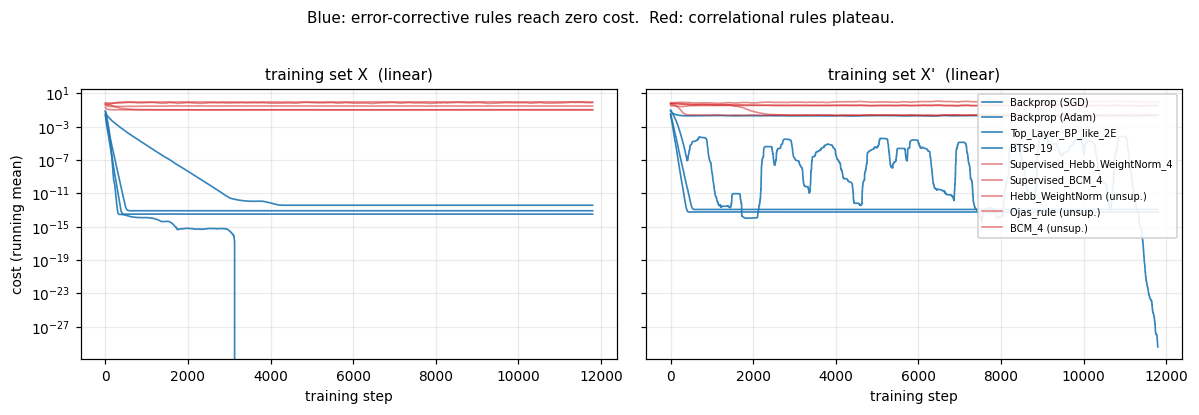

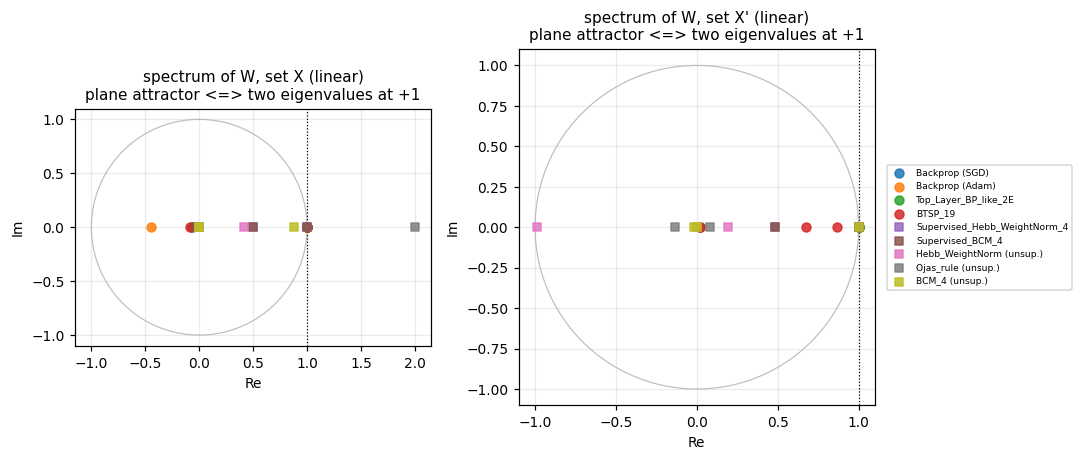

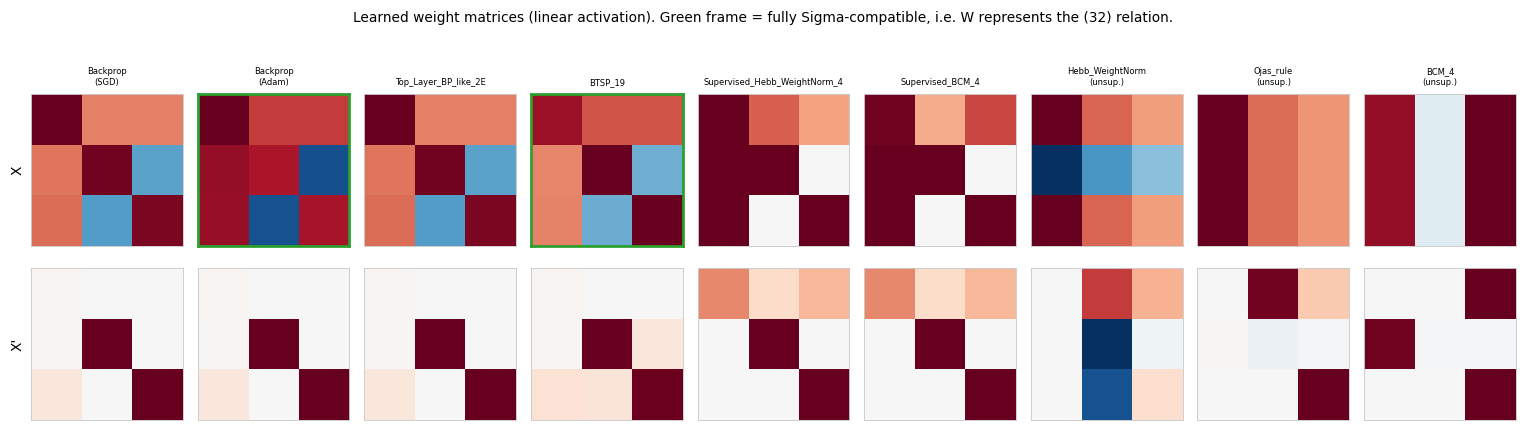

In [ ]:
# ============================================================================
# V.3  Figures - learning curves, eigenvalue spectra, weight structure
# ============================================================================
FAMILY_COLOR = {"error": "#1f77b4", "corr": "#d62728"}


def smooth(v, w=201):
    v = np.asarray(v, dtype=float)
    if len(v) < w:
        return v
    kernel = np.ones(w) / w
    return np.convolve(v, kernel, mode="valid")


# --- learning curves --------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, set_name in zip(axes, X_SETS):
    for cfg_name in RULE_CONFIGS:
        r = results[(set_name, "linear", cfg_name)]
        y = smooth(np.nan_to_num(r["loss_curve"], nan=np.nan, posinf=np.nan))
        ax.plot(y, lw=1.1, color=FAMILY_COLOR[r["family"]],
                alpha=0.9 if r["family"] == "error" else 0.55,
                label=cfg_name)
    ax.set_yscale("log")
    ax.set_xlabel("training step")
    ax.set_title(f"training set {set_name}  (linear)")
axes[0].set_ylabel("cost (running mean)")
axes[1].legend(fontsize=6.5, loc="upper right", ncol=1, framealpha=0.9)
fig.suptitle("Blue: error-corrective rules reach zero cost.  "
             "Red: correlational rules plateau.", y=1.03, fontsize=10)
plt.tight_layout()
plt.show()

# --- eigenvalue spectra in the complex plane --------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4.6))
for ax, set_name in zip(axes, X_SETS):
    theta = np.linspace(0, 2 * np.pi, 200)
    ax.plot(np.cos(theta), np.sin(theta), color="0.75", lw=0.8, zorder=0)
    for i, cfg_name in enumerate(RULE_CONFIGS):
        r = results[(set_name, "linear", cfg_name)]
        if not r["finite"]:
            continue
        ev = r["eigs"]
        ax.scatter(ev.real, ev.imag, s=34, alpha=0.85,
                   marker="o" if r["family"] == "error" else "s",
                   color=plt.cm.tab10(i % 10), label=cfg_name, zorder=3)
    ax.axvline(1.0, color="k", ls=":", lw=0.8)
    ax.set_aspect("equal")
    ax.set_xlabel("Re"); ax.set_ylabel("Im")
    ax.set_title(f"spectrum of W, set {set_name} (linear)\n"
                 "plane attractor <=> two eigenvalues at +1")
axes[1].legend(fontsize=6, loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()

# --- weight matrices --------------------------------------------------------
n_rules = len(RULE_CONFIGS)
fig, axes = plt.subplots(2, n_rules, figsize=(1.55 * n_rules, 4.0))
for row, set_name in enumerate(X_SETS):
    for col, cfg_name in enumerate(RULE_CONFIGS):
        ax = axes[row, col]
        r = results[(set_name, "linear", cfg_name)]
        W = r["W"]
        vmax = np.nanmax(np.abs(W)) if r["finite"] else 1.0
        vmax = max(vmax, 1e-6)
        ax.imshow(np.nan_to_num(W), cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        if row == 0:
            ax.set_title(cfg_name.replace(" ", "\n", 1), fontsize=5.5)
        if col == 0:
            ax.set_ylabel(set_name, fontsize=9)
        ok = r["finite"] and r["sym_frac"] > 0.99
        for spine in ax.spines.values():
            spine.set_edgecolor("#2ca02c" if ok else "#cccccc")
            spine.set_linewidth(1.8 if ok else 0.6)
fig.suptitle("Learned weight matrices (linear activation). "
             "Green frame = fully Sigma-compatible, i.e. W represents the (32) relation.",
             y=1.02, fontsize=9)
plt.tight_layout()
plt.show()

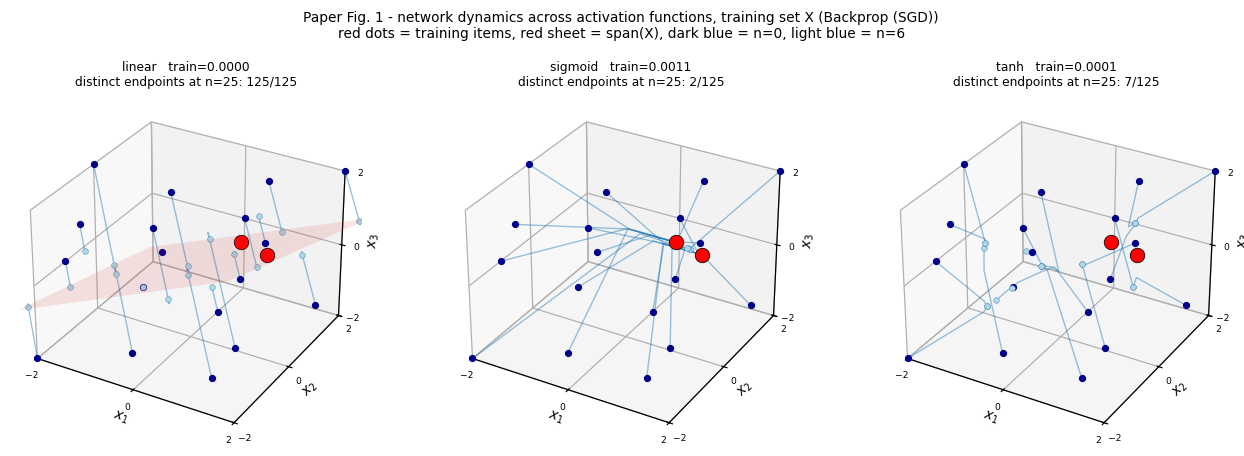

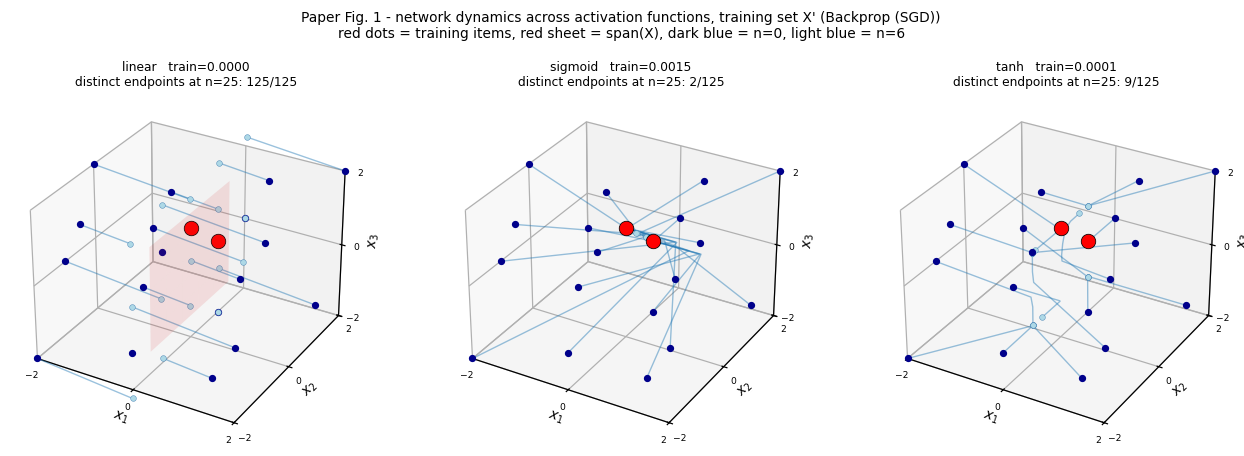

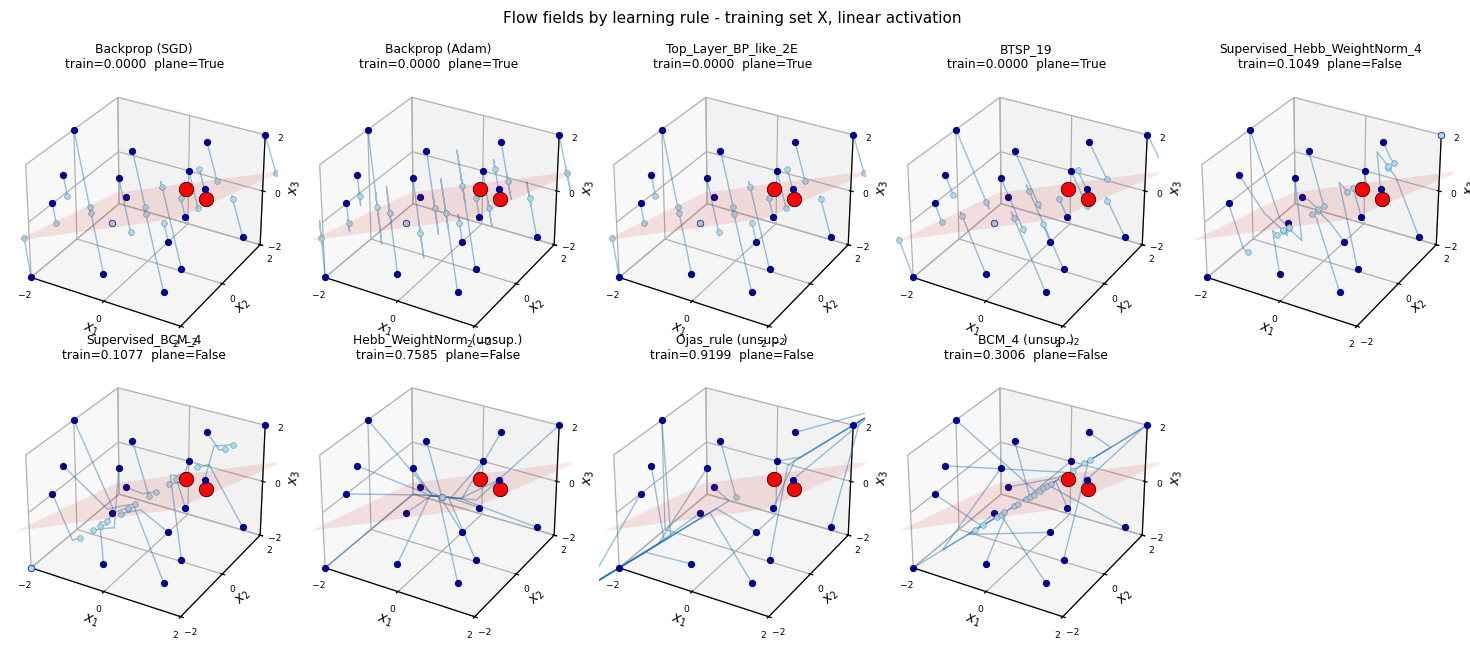

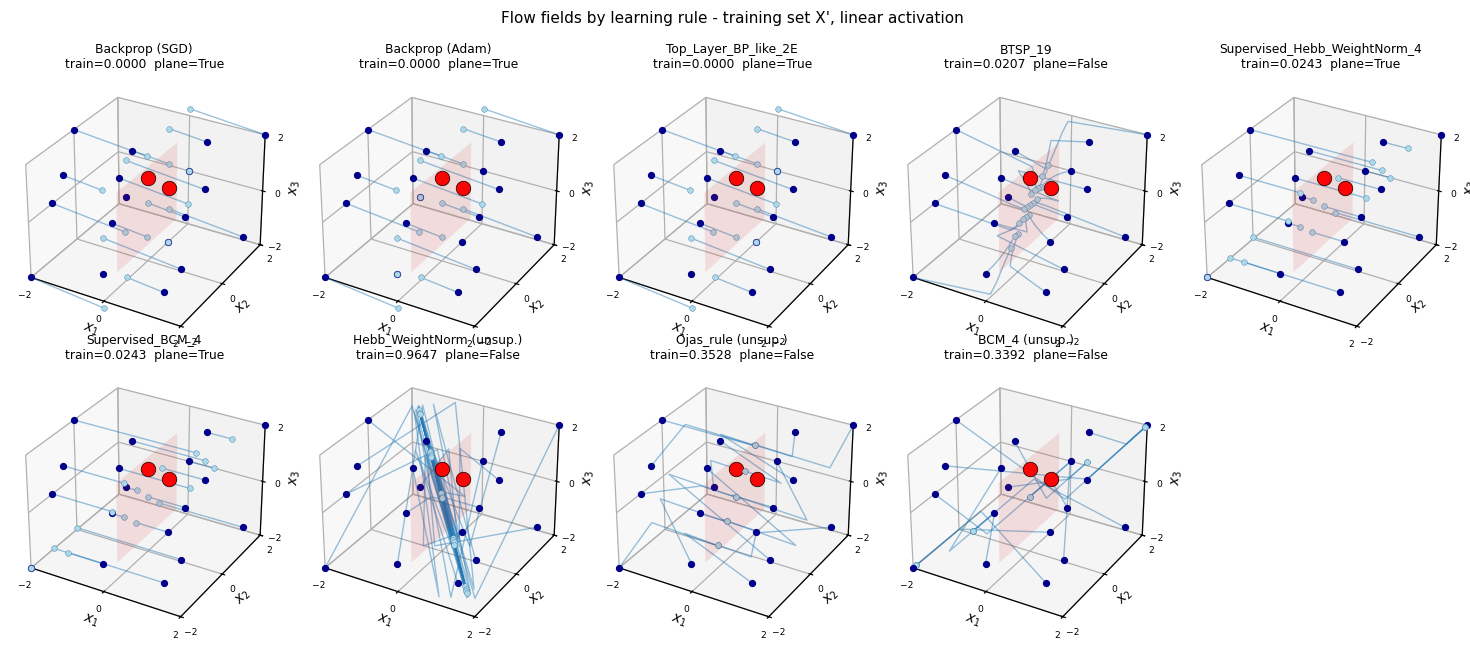

In [ ]:
# ============================================================================
# V.4  Flow fields - the paper's Figure 1
#
# 125 points on a regular 5x5x5 mesh spanning the state space; the network
# function is applied n times to each. Dark blue = n=0, light blue = n=6.
# Fixed points are estimated at n=25.
# ============================================================================
MESH_N = 5
MESH_LIM = 2.0
N_TRAJ_SHOWN = 18
N_STEPS_SHOWN = 6
N_STEPS_FIXED = 25


def flow_field(W, activation="linear", n_points=MESH_N, lim=MESH_LIM,
               n_steps=N_STEPS_SHOWN, clip=1e6):
    """Return (n_steps+1, n_points**3, 3) trajectories of the map x -> phi(Wx)."""
    ax = np.linspace(-lim, lim, n_points)
    pts = np.stack(np.meshgrid(ax, ax, ax, indexing="ij"), axis=-1).reshape(-1, 3)
    phi = ACT_NP[activation]
    traj = [pts.copy()]
    cur = pts.copy()
    with np.errstate(over="ignore", invalid="ignore"):
        for _ in range(n_steps):
            cur = np.clip(phi(cur @ W.T), -clip, clip)
            cur = np.nan_to_num(cur, nan=0.0, posinf=clip, neginf=-clip)
            traj.append(cur.copy())
    return np.stack(traj)


def fixed_points(W, activation="linear", **kw):
    return flow_field(W, activation, n_steps=N_STEPS_FIXED, **kw)[-1]


def plot_flow(ax, traj, items, title, lim=MESH_LIM, n_shown=N_TRAJ_SHOWN,
              show_plane=True):
    idx = np.linspace(0, traj.shape[1] - 1, n_shown, dtype=int)
    for i in idx:
        t = traj[:, i, :]
        ax.plot(t[:, 0], t[:, 1], t[:, 2], color="tab:blue", alpha=0.45, lw=0.9)
        ax.scatter(*t[0], color="darkblue", s=14, depthshade=False)
        ax.scatter(*t[-1], color="lightblue", s=14, depthshade=False,
                   edgecolors="steelblue", linewidths=0.3)

    if show_plane and len(items) == 2:
        u, v = items
        g = np.linspace(-1.4, 1.4, 6)
        A, B = np.meshgrid(g, g)
        P = A[..., None] * u + B[..., None] * v
        ax.plot_surface(P[..., 0], P[..., 1], P[..., 2], alpha=0.12,
                        color="tab:red", shade=False)

    ax.scatter(items[:, 0], items[:, 1], items[:, 2], s=90, c="red",
               depthshade=False, edgecolors="k", linewidths=0.5, zorder=10)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-lim, lim)
    ax.set_xlabel("$x_1$", labelpad=-8); ax.set_ylabel("$x_2$", labelpad=-8)
    ax.set_zlabel("$x_3$", labelpad=-8)
    ax.set_xticks([-2, 0, 2]); ax.set_yticks([-2, 0, 2]); ax.set_zticks([-2, 0, 2])
    ax.tick_params(labelsize=6, pad=-2)
    ax.set_title(title, fontsize=8)


# --- Figure 1 of the paper: activation function sweep, backprop-trained ------
# Use Backprop if it is in RULE_CONFIGS, otherwise the first error-corrective rule.
REF_RULE = next((n for n in ("Backprop (SGD)", "Backprop (Adam)") if n in RULE_CONFIGS),
                next(n for n, c in RULE_CONFIGS.items() if c["family"] == "error"))

for set_name in X_SETS:
    items = X_SETS[set_name]
    fig = plt.figure(figsize=(12, 4.0))
    for j, act in enumerate(("linear", "sigmoid", "tanh")):
        r = results[(set_name, act, REF_RULE)]
        W = r["W"]
        ax = fig.add_subplot(1, 3, j + 1, projection="3d")
        fp = fixed_points(W, act)
        n_fp = len(np.unique(np.round(fp, 2), axis=0))
        # few distinct endpoints => isolated point attractors (associative memory);
        # many => a continuum of fixed points, i.e. a plane/line attractor.
        plot_flow(ax, flow_field(W, act), items,
                  f"{act}   train={r['train_cost']:.4f}\n"
                  f"distinct endpoints at n=25: {n_fp}/125",
                  show_plane=(act == "linear"))
    fig.suptitle(f"Paper Fig. 1 - network dynamics across activation functions, "
                 f"training set {set_name} ({REF_RULE})\n"
                 "red dots = training items, red sheet = span(X), "
                 "dark blue = n=0, light blue = n=6", fontsize=9, y=1.02)
    plt.tight_layout()
    plt.show()

# --- the new axis: flow fields across learning rules (linear activation) -----
for set_name in X_SETS:
    items = X_SETS[set_name]
    names = [n for n in RULE_CONFIGS if results[(set_name, "linear", n)]["finite"]]
    ncol = 5
    nrow = int(np.ceil(len(names) / ncol))
    fig = plt.figure(figsize=(2.7 * ncol, 2.9 * nrow))
    for j, cfg_name in enumerate(names):
        r = results[(set_name, "linear", cfg_name)]
        ax = fig.add_subplot(nrow, ncol, j + 1, projection="3d")
        plot_flow(ax, flow_field(r["W"], "linear"), items,
                  f"{cfg_name}\ntrain={r['train_cost']:.4f}  "
                  f"plane={r['plane']}")
    fig.suptitle(f"Flow fields by learning rule - training set {set_name}, "
                 "linear activation", fontsize=10, y=1.0)
    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================================================
# V.5  Synthesis - the item/relation verdict, computed rather than asserted
# ============================================================================
def verdict(set_name, activation="linear"):
    items = X_SETS[set_name]
    span = set(binary_span_members(items))
    train_keys = {tuple(int(v) for v in r) for r in items}
    generalizable = span - train_keys          # unseen items a linear map can reproduce

    rows = []
    for cfg_name, cfg in RULE_CONFIGS.items():
        r = results[(set_name, activation, cfg_name)]
        if not r["finite"]:
            rows.append((cfg_name, cfg["family"], np.nan, np.nan, False, False))
            continue
        solved = r["train_cost"] < 1e-3
        gen_ok = all(r["test_cost"][int(np.where((ALL_PATTERNS == np.array(p)).all(1))[0][0])] < 1e-3
                     for p in generalizable) if generalizable else None
        rows.append((cfg_name, cfg["family"], r["train_cost"], r["sym_resid"],
                     solved, bool(gen_ok) if gen_ok is not None else False))

    hdr = f"{'learning rule':<30}{'family':<8}{'solves task':>13}{'builds plane':>14}{'generalizes':>13}"
    print(f"\n### Verdict - training set {set_name}, {activation} activation")
    print(f"    unseen items reachable by a linear auto-associator: "
          f"{sorted(generalizable) if generalizable else 'none'}")
    print("=" * len(hdr))
    print(hdr)
    print("-" * len(hdr))
    for cfg_name, fam, tc, resid, solved, gen_ok in rows:
        r = results[(set_name, activation, cfg_name)]
        print(f"{cfg_name:<30}{fam:<8}{str(solved):>13}{str(r['plane']):>14}{str(gen_ok):>13}")
    print("-" * len(hdr))

    n_err = sum(1 for _, f, *_ in rows if f == "error")
    err_solved = sum(1 for _, f, _, _, s, _ in rows if f == "error" and s)
    corr_solved = sum(1 for _, f, _, _, s, _ in rows if f == "corr" and s)
    n_corr = len(rows) - n_err
    print(f"  error-corrective rules solving the task : {err_solved}/{n_err}")
    print(f"  correlational  rules solving the task   : {corr_solved}/{n_corr}")


for s in X_SETS:
    verdict(s, "linear")

# --- activation sweep: does generalization survive the non-linearity? -------
print("\n\n### Effect of the activation function (training set X', "
      "error-corrective rules only)")
hdr = f"{'learning rule':<30}" + "".join(f"{a:>22}" for a in ("linear", "tanh", "sigmoid"))
print("=" * len(hdr)); print(hdr)
print(f"{'':<30}" + "".join(f"{'train / unseen':>22}" for _ in range(3)))
print("-" * len(hdr))
items = X_SETS["X'"]
train_keys = {tuple(int(v) for v in r) for r in items}
unseen_span = sorted(set(binary_span_members(items)) - train_keys)
for cfg_name, cfg in RULE_CONFIGS.items():
    if cfg["family"] != "error":
        continue
    line = f"{cfg_name:<30}"
    for act in ("linear", "tanh", "sigmoid"):
        r = results[("X'", act, cfg_name)]
        if not r["finite"]:
            line += f"{'diverged':>22}"
            continue
        idx = [int(np.where((ALL_PATTERNS == np.array(p)).all(1))[0][0]) for p in unseen_span]
        line += f"{r['train_cost']:>11.4f} /{np.mean(r['test_cost'][idx]):>9.4f}"
    print(line)
print("-" * len(hdr))
print(f"  'unseen' = mean cost on {unseen_span}, the non-training binary points of span(X')")
print("  The paper's claim: linear ~ 0, tanh small (it has a linear regime near 0),")
print("  sigmoid large (it is non-linear exactly where the binary values live).")


### Verdict - training set X, linear activation
    unseen items reachable by a linear auto-associator: [(0, 0, 0)]
learning rule                 family    solves task  builds plane  generalizes
------------------------------------------------------------------------------
Backprop (SGD)                error            True          True         True
Backprop (Adam)               error            True          True         True
Top_Layer_BP_like_2E          error            True          True         True
BTSP_19                       error            True          True         True
Supervised_Hebb_WeightNorm_4  corr            False         False         True
Supervised_BCM_4              corr            False         False         True
Hebb_WeightNorm (unsup.)      corr            False         False         True
Ojas_rule (unsup.)            corr            False         False         True
BCM_4 (unsup.)                corr            False         False         True
--------------

---
# Part VI — Summary

## What the analytics say (Part I, verified with SymPy)

The symmetry group of both training sets is $\Sigma = \{e, (32)\}$, found by brute force over $S_3$.
Solving $W = s\cdot W$ gives the five-parameter compatible structure
$W = \begin{pmatrix} a&b&b\\ c&d&e\\ c&e&d\end{pmatrix}$, and imposing the fixed-point equations on
each orbit collapses it to the two-parameter families

$$W_{a,b} = \begin{pmatrix}1-a & a & a\\ -b & 1+b & b\\ -b & b & 1+b\end{pmatrix},\qquad
  W'_{a,b} = \begin{pmatrix}a & 0 & 0\\ b & 1 & 0\\ b & 0 & 1\end{pmatrix}$$

with spectra $\{1-a+2b, 1, 1\}$ and $\{a, 1, 1\}$. **Two eigenvalues are pinned at 1** — that is the
invariant plane. The third sets whether the plane attracts.

## What the numerics say

**Along the optimizer axis (Part II).** Every converged solution is a member of the family; which
member depends on the optimizer and the initialization, exactly as claimed. Zeros- and ones-init SGD
reproduce the paper's published $W_0^{SGD}$ and $W_1^{SGD}$ to better than $10^{-3}$. A single
random-init run is *not* $\Sigma$-compatible — rows 2 and 3 stop being mirror images — but
$\mathbf{E}[W]$ over 200 realizations recovers the symmetry. So the symmetry lives in the ensemble,
not necessarily in any one network.

**Along the learning-rule axis (Parts IV–V).** The rules split cleanly, and the split is not about
biological plausibility — it is about whether the update has a zero-error fixed point:

* **Error-corrective** — `Backprop`, `Top_Layer_BP_like_2E`, `BTSP_19`. The update is driven by
  $\mathrm{clamp}(t-y)$, so it vanishes exactly when the auto-association task is solved. All three
  reach zero training cost and land inside the analytical family, with the eigenvalue-1 pair and a
  contracting third — a plane attractor, hence generalization to the unseen items of
  $\mathrm{span}(X)$. `Top_Layer_BP_like_2E` on a linear readout *is* the delta rule (checked
  exactly in the self-test); `BTSP_19` gets there by a very different route, through an eligibility
  trace and a weight-dependent saturating update.
* **Correlational** — `Hebb_WeightNorm`, `Ojas_rule`, `BCM_4` and the nudged `Supervised_*`
  variants. The update is a product of activities with no zero-error fixed point. None reaches zero
  cost. Nudging the output toward the target helps substantially — the supervised variants beat
  their unsupervised counterparts everywhere — but a Hebbian product plus a norm constraint is not
  an error-correcting rule. Two qualifications the measurements forced:
  * *They do not all diverge.* Only unsupervised `Hebb_WeightNorm` blows up without a constraint
    (to $10^{152}$ by 12k steps). Both BCM variants are self-stabilizing, which is precisely what
    the sliding threshold is for.
  * *One of them does build a plane attractor.* `Supervised_Hebb_WeightNorm_4` on $X'$ with
    `scale=1.0` reaches cost 0.06 with spectrum $\{1, 1, 0.145\}$. The boundary between the two
    families is not perfectly sharp: a nudged Hebbian rule under the right norm constraint can
    approximate an error-correcting one.

**An aside on BTSP.** Its eligibility trace also associates each item with the *previous* sample
(`temporal_discount=0.25`). On $X$ this is harmless — both items share their first component — but
on $X'$, whose items are disjoint one-hot vectors, it creates exactly the off-diagonal weights the
task forbids, leaving a residual cost of ~0.02. Setting `temporal_discount=0` solves both sets
exactly. Whether temporal binding helps or hurts depends on the temporal structure of the training
set; backprop has no such sensitivity. This is a property of the rule that the paper's task happens
to expose, and it is not visible on the benchmarks EIANN was designed for.

**Along the activation axis.** The paper's ordering is reproduced: linear generalizes exactly, tanh
generalizes approximately because it is near-linear around 0, and sigmoid fails on the unseen items
because it is strongly non-linear precisely at 0 and 1, where the binary patterns live. Its flow
field collapses onto isolated fixed points — associative memory, i.e. *items*.

## The synthesis

The paper's dichotomy is really about **dynamics, not architecture**: a network represents
*relations* when its learned map has an invariant subspace matching the span of the training set, and
represents *items* when it has isolated point attractors. That criterion is imposed jointly by

1. the **activation function** — it must have a linear regime where the data live, and
2. the **learning rule** — it must have a fixed point at zero error.

Neither alone is sufficient. A linear network trained with a purely Hebbian rule stores items (or
principal components); a sigmoid network trained with backprop also stores items. Generalization in
this setting needs both.

---

## Extending this notebook

Everything is parameterised, so the following are one-liners:

* **A different symmetry group.** Change `X_SETS`; `symmetry_group`, `compatible_structure_mask` and
  `binary_span_members` are all computed, not hard-coded, so Parts I and V adapt automatically.
* **Larger patterns.** Set `size=N` in `build_autoassociator` and use length-$N$ binary items.
  `ALL_PATTERNS` would need regenerating for $N \neq 3$.
* **A hidden layer.** `Network` takes an arbitrary chain of layers; add an `H1` entry to
  `layer_spec` and a second projection. Note that the supervised local rules implemented here nudge
  only the *output* population — for hidden layers EIANN uses `BP_like_2E` / `BP_like_2L`, which
  additionally propagate a dendritic error, and those are not reimplemented here.
* **A new rule.** Subclass `LearningRule`, decorate with `@register_rule`, add an entry to
  `RULE_CONFIGS`. Add `_SupervisedNudge` as a base class if it should see the target.
* **Regularization.** The paper's §4 conjecture — that L1/L2 or firing-rate regularization improves
  generalization for tanh by pushing it into its linear regime — is not tested here and would be a
  natural next experiment.